# Figuras y tablas del paper

## FIG MARGINALS VS JOIN 

In [21]:
%pip install -q tueplots

Note: you may need to restart the kernel to use updated packages.


In [22]:
from pathlib import Path
import sys
import warnings
import torch.distributions as D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from matplotlib.gridspec import GridSpec
from tueplots import bundles

cwd = Path.cwd().resolve()
if (cwd / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd
elif (cwd.parent / 'src' / 'jensenshannondivergence').exists():
    project_root = cwd.parent
else:
    project_root = Path('/home/alba/snap/snapd-desktop-integration/jensenshannondivergence')
src_root = project_root / 'src'
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from jensenshannondivergence.data_utils import create_corr_mvn

warnings.filterwarnings("ignore", message=".*tight_layout.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*layout has changed to tight.*", category=UserWarning)

### Visual comparison between distributions with different dependencies

The figure shows samples from the real distribution (P) and from synthetic distributions (Q) for different correlation values (\rho). Each panel combines the joint distribution in the ((x_0, x_1)) plane with the corresponding marginal distributions. This visualization shows that the marginals can be nearly indistinguishable even when the dependency structure between variables changes substantially.


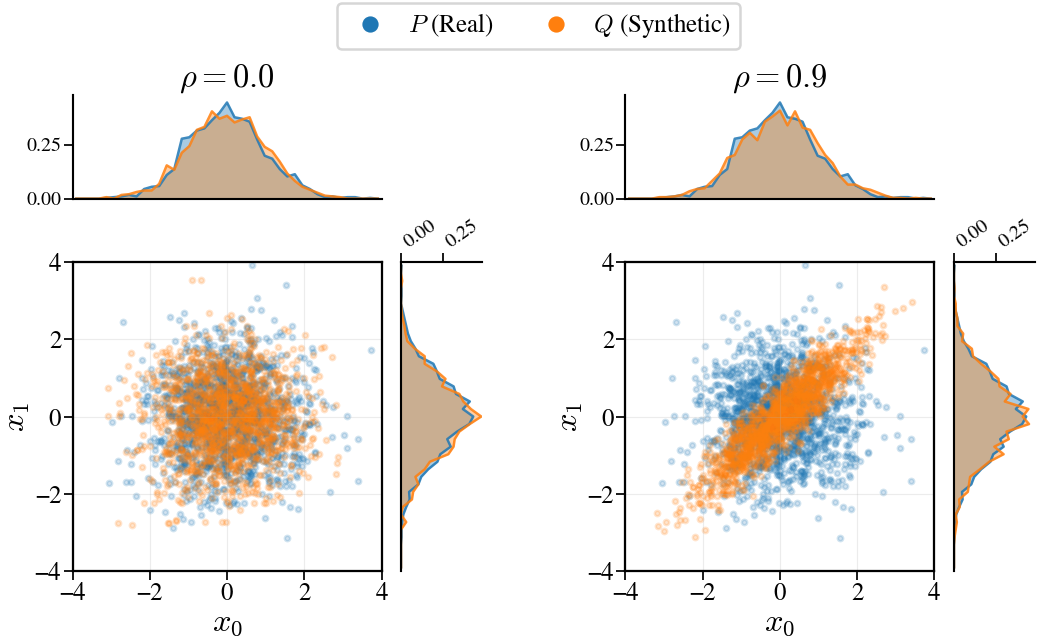

In [23]:
def plot_use_case5_compact_improved_axes(output_path, rho_values=(0.0, 0.9), n_samples=1500, seed=0, filename="marginals_paper.png"):
    rho_values = [float(r) for r in rho_values]
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(seed)
    np.random.seed(seed)

    dist_p = create_corr_mvn(n_dims=2, rho=0.0)
    x_p = dist_p.sample(torch.Size((n_samples,))).numpy()

    color_p, color_q = "#1f77b4", "#ff7f0e"

    style = {
        **bundles.icml2022(), "text.usetex": False, "font.size": 12,
        "axes.labelsize": 13, "axes.titlesize": 13,
        "xtick.labelsize": 10, "ytick.labelsize": 10,
        "legend.fontsize": 10, "axes.linewidth": 0.85,
        "grid.linewidth": 0.45, "lines.linewidth": 1.2,
        "figure.dpi": 180, "savefig.dpi": 300,
    }

    def marginal_density(values, bins):
        counts, edges = np.histogram(values, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return centers, counts

    with plt.rc_context(style):
        fig = plt.figure(figsize=(6.9, 3.75), dpi=180)
        outer_gs = GridSpec(1, len(rho_values), figure=fig, wspace=0.35)

        bins = np.linspace(-4.0, 4.0, 42)
        side_axes_to_align = []

        for col, rho in enumerate(rho_values):
            dist_q = create_corr_mvn(n_dims=2, rho=rho)
            x_q = dist_q.sample(torch.Size((n_samples,))).numpy()

            inner_gs = outer_gs[col].subgridspec(
                2, 2, width_ratios=[4.0, 1.05], height_ratios=[1.05, 4.0],
                hspace=0.08, wspace=0.10,
            )

            ax_scatter = fig.add_subplot(inner_gs[1, 0])
            ax_hist_x = fig.add_subplot(inner_gs[0, 0], sharex=ax_scatter)
            ax_hist_y = fig.add_subplot(inner_gs[1, 1], sharey=ax_scatter)
            fig.add_subplot(inner_gs[0, 1]).axis("off")

            side_axes_to_align.append((ax_scatter, ax_hist_y))

            # Scatter
            ax_scatter.scatter(x_p[:, 0], x_p[:, 1], s=4.5, alpha=0.20, color=color_p, rasterized=True)
            ax_scatter.scatter(x_q[:, 0], x_q[:, 1], s=4.5, alpha=0.20, color=color_q, rasterized=True)

            ax_scatter.set_aspect("equal", adjustable="box")
            ax_scatter.set_xlim(-4.0, 4.0)
            ax_scatter.set_ylim(-4.0, 4.0)
            ax_scatter.set_xlabel(r"$x_0$", labelpad=1)
            ax_scatter.set_ylabel(r"$x_1$", labelpad=1)
            ax_scatter.grid(True, alpha=0.24)
            ax_scatter.tick_params(axis="both", pad=1)

            for spine in ax_scatter.spines.values():
                spine.set_linewidth(0.9)

            # Top marginal
            cx_p, dx_p = marginal_density(x_p[:, 0], bins)
            cx_q, dx_q = marginal_density(x_q[:, 0], bins)

            ax_hist_x.fill_between(cx_p, 0, dx_p, color=color_p, alpha=0.38, linewidth=0)
            ax_hist_x.fill_between(cx_q, 0, dx_q, color=color_q, alpha=0.38, linewidth=0)
            ax_hist_x.plot(cx_p, dx_p, color=color_p, linewidth=1.0, alpha=0.85)
            ax_hist_x.plot(cx_q, dx_q, color=color_q, linewidth=1.0, alpha=0.85)

            ax_hist_x.set_title(rf"$\rho={rho:.1f}$", pad=3)
            ax_hist_x.set_ylim(0, 0.48)
            ax_hist_x.set_yticks([0.0, 0.25])
            ax_hist_x.set_yticklabels(["0.00", "0.25"])
            ax_hist_x.tick_params(axis="x", labelbottom=False, bottom=False)
            ax_hist_x.tick_params(axis="y", pad=1, labelsize=8)
            ax_hist_x.grid(False)
            ax_hist_x.spines["top"].set_visible(False)
            ax_hist_x.spines["right"].set_visible(False)

            # Right marginal
            cy_p, dy_p = marginal_density(x_p[:, 1], bins)
            cy_q, dy_q = marginal_density(x_q[:, 1], bins)

            ax_hist_y.fill_betweenx(cy_p, 0, dy_p, color=color_p, alpha=0.38, linewidth=0)
            ax_hist_y.fill_betweenx(cy_q, 0, dy_q, color=color_q, alpha=0.38, linewidth=0)
            ax_hist_y.plot(dy_p, cy_p, color=color_p, linewidth=1.0, alpha=0.85)
            ax_hist_y.plot(dy_q, cy_q, color=color_q, linewidth=1.0, alpha=0.85)

            ax_hist_y.set_xlim(0, 0.48)
            ax_hist_y.set_ylim(-4.0, 4.0)
            ax_hist_y.margins(y=0)
            ax_hist_y.set_xticks([0.0, 0.25])
            ax_hist_y.set_xticklabels(["0.00", "0.25"], rotation=35, ha="left", va="bottom")
            ax_hist_y.xaxis.set_ticks_position("top")
            ax_hist_y.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False, pad=1, labelsize=8)
            ax_hist_y.tick_params(axis="y", labelleft=False, left=False)
            ax_hist_y.grid(False)

            ax_hist_y.spines["left"].set_visible(True)
            ax_hist_y.spines["left"].set_linewidth(0.85)
            ax_hist_y.spines["right"].set_visible(False)
            ax_hist_y.spines["top"].set_visible(True)
            ax_hist_y.spines["top"].set_linewidth(0.85)
            ax_hist_y.spines["bottom"].set_visible(False)

        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=color_p,
                       markeredgecolor=color_p, markersize=5.5, label=r"$P$ (Real)"),
            plt.Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=color_q,
                       markeredgecolor=color_q, markersize=5.5, label=r"$Q$ (Synthetic)"),
        ]

        fig.legend(
            handles=handles, loc="upper center", ncol=2, frameon=True,
            bbox_to_anchor=(0.5, 1.035), columnspacing=1.5,
            handletextpad=0.5, borderpad=0.35,
        )

        fig.tight_layout(rect=[0, 0, 1, 0.89])

        # Force side marginals to have exactly the same vertical span as scatter panels.
        fig.canvas.draw()
        for ax_scatter, ax_hist_y in side_axes_to_align:
            scatter_pos = ax_scatter.get_position()
            side_pos = ax_hist_y.get_position()
            ax_hist_y.set_position([side_pos.x0, scatter_pos.y0, side_pos.width, scatter_pos.height])

        save_png = output_path / filename
        save_pdf = output_path / filename.replace(".png", ".pdf")
        fig.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.025)
        fig.savefig(save_pdf, bbox_inches="tight", pad_inches=0.025)
        plt.show()
        plt.close(fig) 

plot_use_case5_compact_improved_axes(
    output_path="results_discriminators/use_case_5/figures",
    rho_values=(0.0, 0.9),
    n_samples=1500,
    seed=0,
)

### Visual comparison of distribution gap scenarios

This figure illustrates controlled distribution-shift scenarios between a real distribution \(P\) and a synthetic distribution \(Q\). Both distributions are modeled as two-dimensional Gaussians with different covariance structures, while the mean of \(Q\) is progressively shifted along the direction \((1, -1)\). The parameter \(k\) controls the magnitude of this gap. Each panel shows samples from both distributions, density contours, and the displacement between their means, providing an intuitive visualization of how the separation between \(P\) and \(Q\) increases as \(k\) grows.

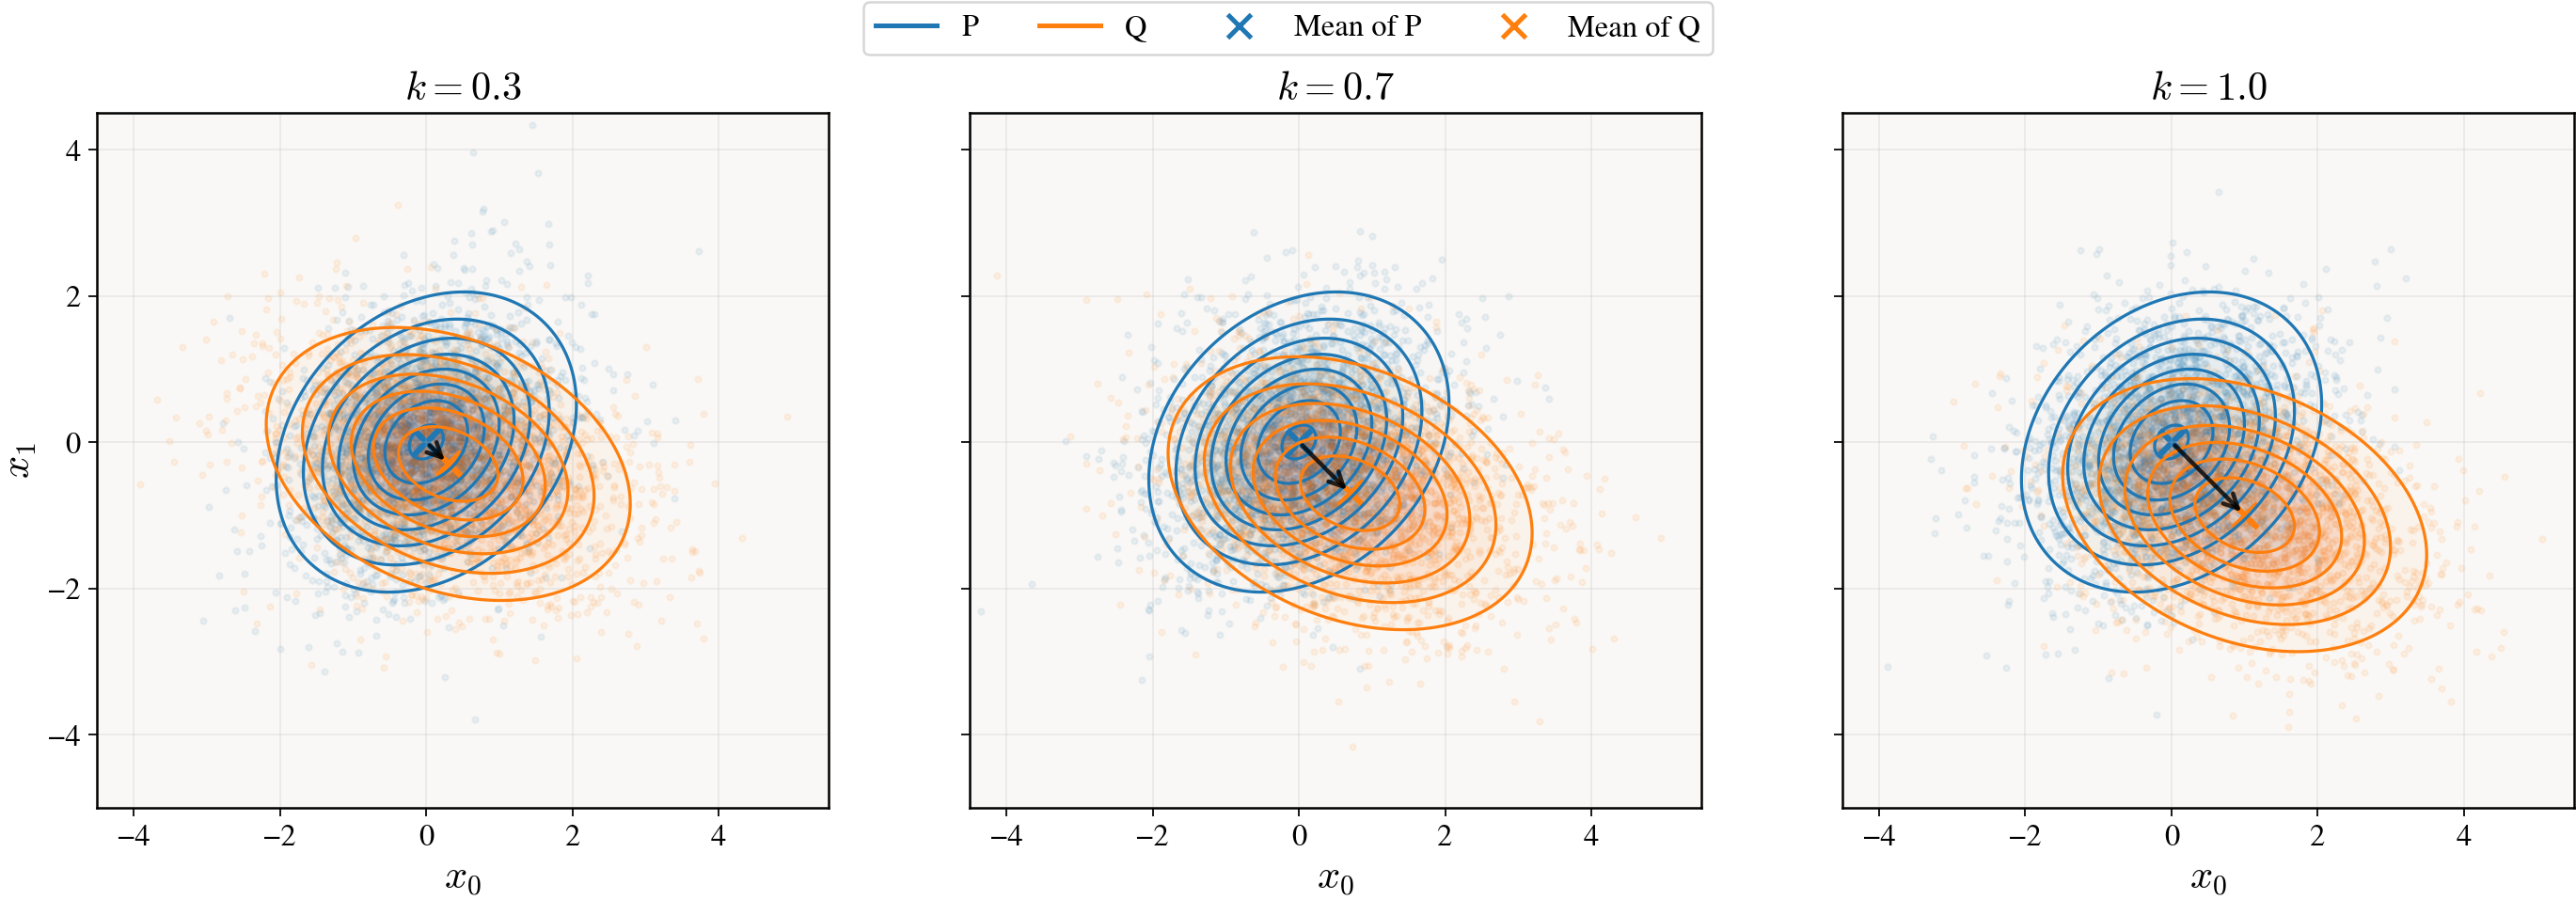

Saved in: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_6/figures/gap_scenarios_paper.png


In [24]:
def create_uc6_distributions(gap_magnitude=0.7):
    """P and Q for Use Case 6."""
    loc_p = torch.tensor([0.0, 0.0], dtype=torch.float32)
    cov_p = torch.tensor([[1.0, 0.25], [0.25, 1.0]], dtype=torch.float32)

    base_direction = torch.tensor([1.0, -1.0], dtype=torch.float32)
    loc_q = loc_p + gap_magnitude * base_direction
    cov_q = torch.tensor([[1.6, -0.35], [-0.35, 0.9]], dtype=torch.float32)

    dist_p = D.MultivariateNormal(loc_p, covariance_matrix=cov_p)
    dist_q = D.MultivariateNormal(loc_q, covariance_matrix=cov_q)

    return dist_p, dist_q, loc_p.numpy(), cov_p.numpy(), loc_q.numpy(), cov_q.numpy()


def gaussian_pdf_grid(xx, yy, mean, cov):
    """Evaluate a 2D Gaussian PDF on a grid."""
    pos = np.dstack((xx, yy))
    inv_cov, det_cov = np.linalg.inv(cov), np.linalg.det(cov)
    diff = pos - mean
    exponent = np.einsum("...i,ij,...j->...", diff, inv_cov, diff)
    return np.exp(-0.5 * exponent) / (2.0 * np.pi * np.sqrt(det_cov))


def plot_uc6_gaps(
    output_path, gap_values=(0.3, 0.7, 1), n_samples=2000, seed=0,
    ratio_for_visualization=1.0, filename="gap_scenarios_paper.png"
):
    """Visualize UC6 gap scenarios: P = N([0, 0], cov_p), Q = N([k, -k], cov_q)."""
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(seed)
    np.random.seed(seed)

    color_p, color_q = "#1f77b4", "#ff7f0e"

    style = {
        **bundles.icml2022(), "text.usetex": False, "font.size": 15,
        "axes.labelsize": 17, "axes.titlesize": 17,
        "xtick.labelsize": 13, "ytick.labelsize": 13,
        "legend.fontsize": 13, "figure.dpi": 180, "savefig.dpi": 300,
        "axes.linewidth": 1.0, "grid.linewidth": 0.6,
    }

    x = np.linspace(-4.5, 5.5, 350)
    y = np.linspace(-5.0, 4.5, 350)
    xx, yy = np.meshgrid(x, y)

    with plt.rc_context(style):
        fig, axes = plt.subplots(
            1, len(gap_values), figsize=(5.4 * len(gap_values), 5.2),
            sharex=True, sharey=True,
        )
        axes = [axes] if len(gap_values) == 1 else axes

        for ax, gap in zip(axes, gap_values):
            dist_p, dist_q, mean_p, cov_p, mean_q, cov_q = create_uc6_distributions(float(gap))

            n_q = max(int(ratio_for_visualization * n_samples), 4)
            x_p = dist_p.sample(torch.Size((n_samples,))).numpy()
            x_q = dist_q.sample(torch.Size((n_q,))).numpy()

            z_p = gaussian_pdf_grid(xx, yy, mean_p, cov_p)
            z_q = gaussian_pdf_grid(xx, yy, mean_q, cov_q)

            ax.scatter(x_p[:, 0], x_p[:, 1], s=6, alpha=0.12, color=color_p, rasterized=True, label="P")
            ax.scatter(x_q[:, 0], x_q[:, 1], s=6, alpha=0.12, color=color_q, rasterized=True, label="Q")

            ax.contourf(xx, yy, z_p, levels=8, cmap="Blues", alpha=0.22)
            ax.contour(xx, yy, z_p, levels=8, colors=color_p, linewidths=1.3)
            ax.contourf(xx, yy, z_q, levels=8, cmap="Oranges", alpha=0.22)
            ax.contour(xx, yy, z_q, levels=8, colors=color_q, linewidths=1.3)

            ax.scatter(mean_p[0], mean_p[1], marker="x", s=110, linewidths=2.5, color=color_p)
            ax.scatter(mean_q[0], mean_q[1], marker="x", s=110, linewidths=2.5, color=color_q)

            ax.annotate(
                "", xy=(mean_q[0], mean_q[1]), xytext=(mean_p[0], mean_p[1]),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="black", alpha=0.8),
            )

            ax.set_title(rf"$k = {gap:.1f}$")
            ax.set_xlabel(r"$x_0$")
            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.25)
            ax.set_xlim(-4.5, 5.5)
            ax.set_ylim(-5.0, 4.5)

        axes[0].set_ylabel(r"$x_1$")

        handles = [
            plt.Line2D([0], [0], color=color_p, lw=2, label="P"),
            plt.Line2D([0], [0], color=color_q, lw=2, label="Q"),
            plt.Line2D([0], [0], marker="x", color=color_p, lw=0, markersize=10,
                       markeredgewidth=2, label=r"Mean of P"),
            plt.Line2D([0], [0], marker="x", color=color_q, lw=0, markersize=10,
                       markeredgewidth=2, label=r"Mean of Q"),
        ]

        fig.legend(handles=handles, loc="upper center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 1.03))
        fig.tight_layout(rect=[0, 0, 1, 0.93])

        save_path = output_path / filename
        fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.03)

        plt.show()
        plt.close(fig)

    print(f"Saved in: {save_path.resolve()}")


plot_uc6_gaps(
    output_path="results_discriminators/use_case_6/figures",
    gap_values=(0.3, 0.7, 1),
    n_samples=2000,
    seed=0,
    ratio_for_visualization=1.0,
)

### Jensen-Shannon estimates as a function of training sample size

This figure compares different empirical Jensen-Shannon divergence estimators as the training sample size \(N\) increases. For each method, the plot reports \(\widehat{D}_{\mathrm{JS}}\) using the largest available values of \(M\) and \(L\) in the experimental grid. The reference Monte Carlo estimate \(D_{\mathrm{JS}}^{\star}\) is shown together with discriminator-based and marginal/synthetic-data-based estimators, highlighting how estimator behavior changes with sample size.

Saved in: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_3/figures/js_estimation_vs_N_use_case3_paper.png
Saved in: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_3/figures/js_estimation_vs_N_use_case3_paper.pdf


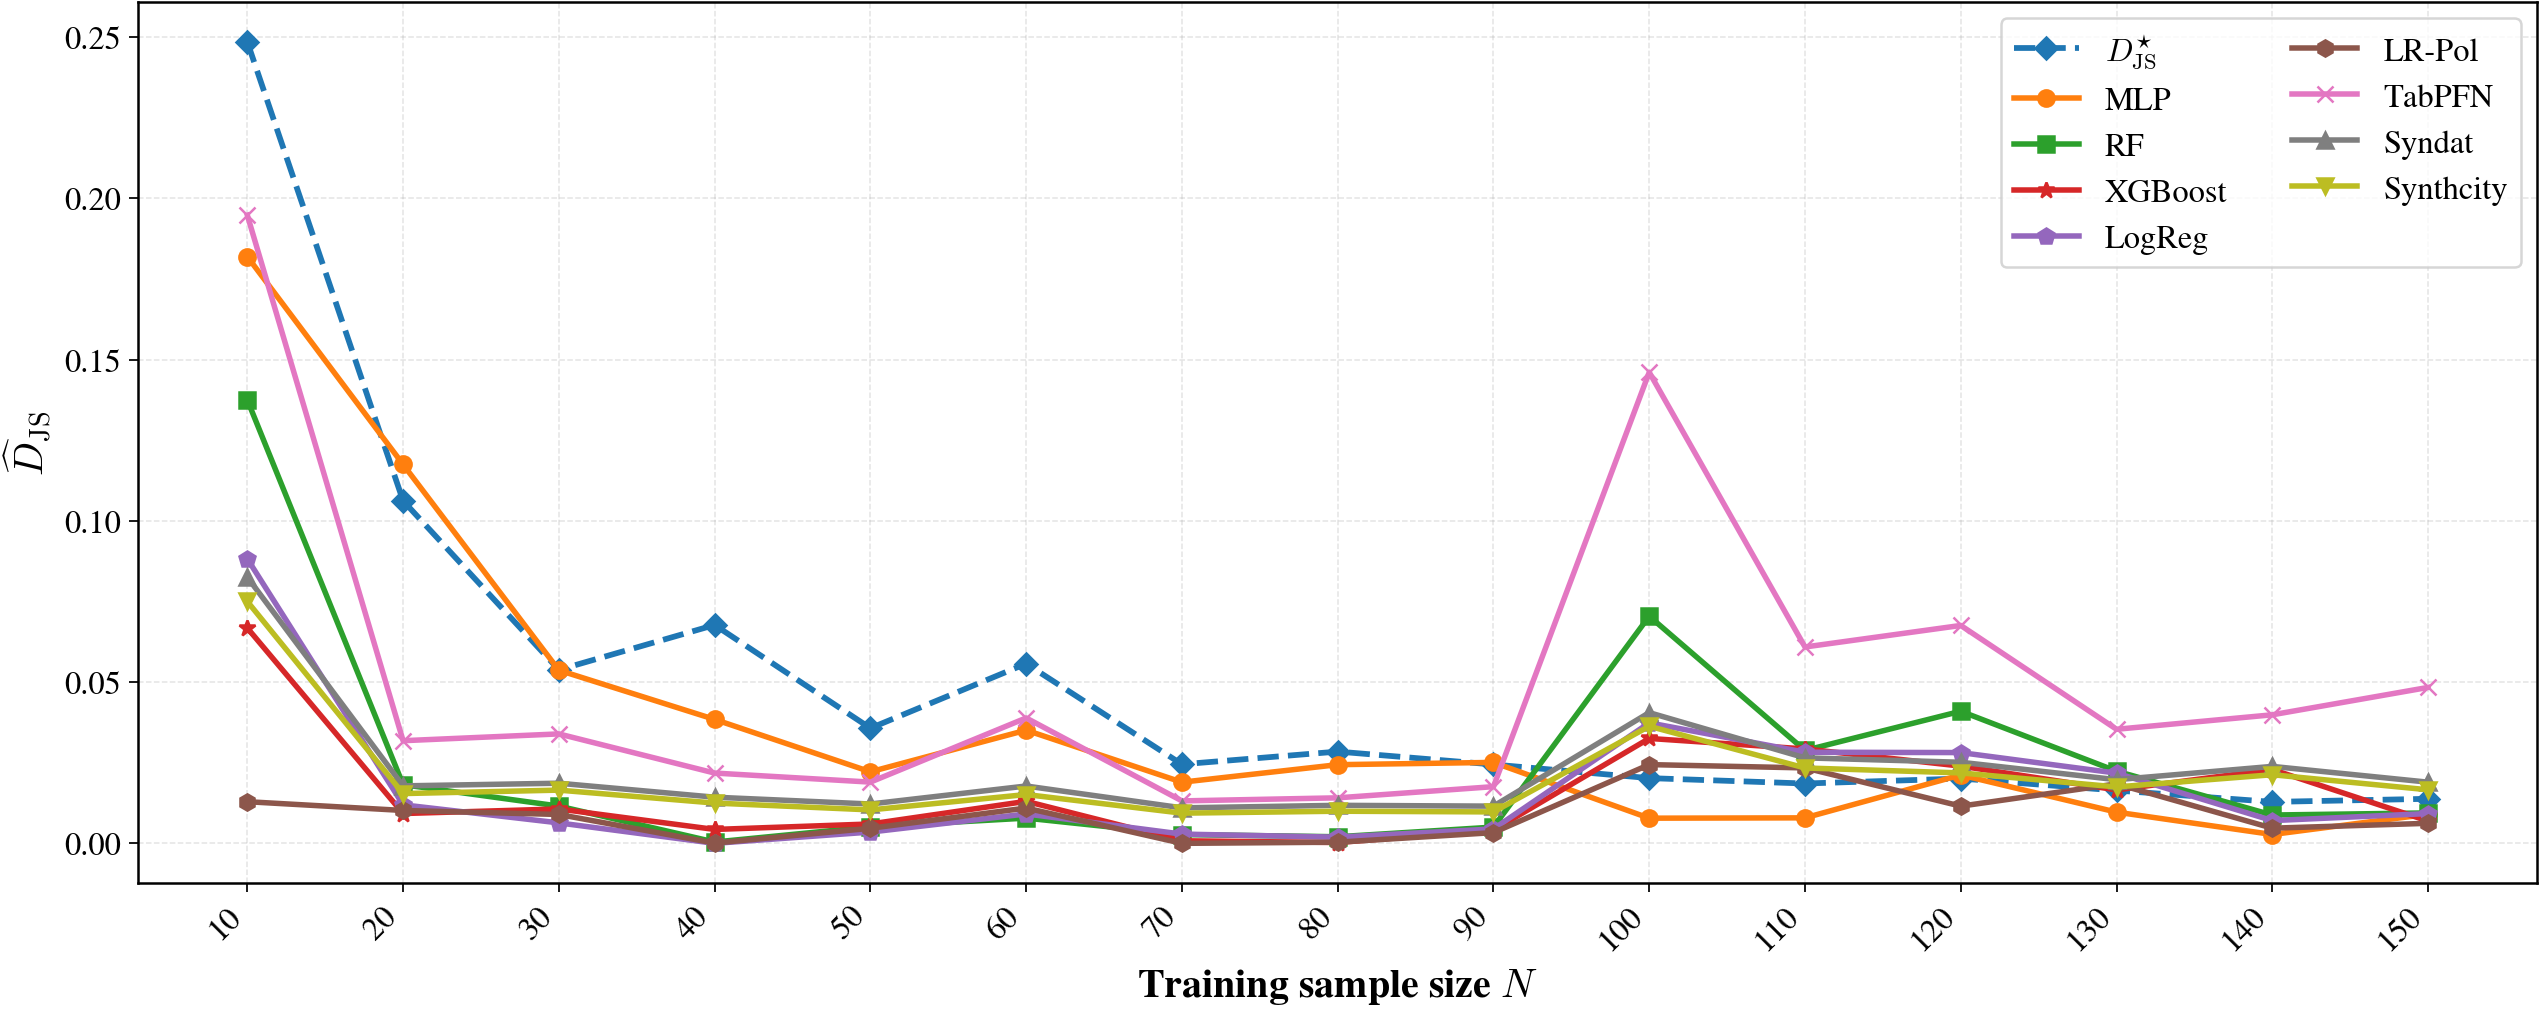

In [25]:
style = {
    **bundles.icml2022(), "text.usetex": False, "font.size": 14,
    "axes.labelsize": 16, "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 13, "axes.linewidth": 1.0, "grid.linewidth": 0.6,
    "figure.dpi": 180, "savefig.dpi": 300, "legend.frameon": True,
}
plt.rcParams.update(style)

csv_path = Path("results_discriminators/use_case_3/comparison_js.csv")
assert csv_path.exists(), f"File not found: {csv_path.resolve()}"

df_uc3 = pd.read_csv(csv_path).sort_values(["N", "M", "L"])
m_ref, l_ref = int(df_uc3["M"].max()), int(df_uc3["L"].max())
df_plot = df_uc3.query("M == @m_ref and L == @l_ref").sort_values("N").copy()
assert not df_plot.empty, "No rows for the reference pair (M, L)."

method_specs = [
    ("GT MC JS", r"$D_{\mathrm{JS}}^{\star}$", "--", "D", 2.3),
    ("Disc JS (MLP)", "MLP", "-", "o", 2.2),
    ("Disc JS (RF)", "RF", "-", "s", 2.2),
    ("Disc JS (XGBoost)", "XGBoost", "-", "*", 2.2),
    ("Disc JS (LogReg)", "LogReg", "-", "p", 2.2),
    ("Disc JS (LogRegPol)", "LR-Pol", "-", "h", 2.2),
    ("Disc JS (TabPFN)", "TabPFN", "-", "x", 2.2),
    ("Syndat JS", "Syndat", "-", "^", 2.2),
    ("Synthcity JS", "Synthcity", "-", "v", 2.2),
]

x = df_plot["N"].astype(int).to_numpy()

fig, ax = plt.subplots(figsize=(14.5, 6.0), dpi=180)

for column, label, linestyle, marker, linewidth in method_specs:
    if column not in df_plot:
        continue

    y = pd.to_numeric(df_plot[column], errors="coerce").to_numpy()
    if pd.isna(y).all():
        continue

    ax.plot(
        x, y, label=label, linestyle=linestyle, marker=marker,
        linewidth=linewidth, markersize=6.5,
    )

ax.set_xlabel("Training sample size $N$", fontweight="bold")
ax.set_ylabel(r"$\widehat{D}_{\mathrm{JS}}$", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in x], rotation=45, ha="right")
ax.grid(True, alpha=0.35, linestyle="--")
ax.legend(loc="upper right", frameon=True, ncol=2)

plt.tight_layout()

out_dir = Path("results_discriminators/use_case_3/figures")
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "pdf"]:
    out_path = out_dir / f"js_estimation_vs_N_use_case3_paper.{ext}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved in: {out_path.resolve()}")

plt.show()
plt.close(fig)

### Estimation error under changing dependency structure

This figure evaluates how the absolute error of different Jensen-Shannon divergence estimators changes as the correlation parameter \(\rho\) varies. For each value of \(\rho\), the plot reports the mean absolute deviation from the Monte Carlo reference \(D_{\mathrm{JS}}^{\star}\), using either standard deviation or 95% confidence intervals across seeds. This setting highlights how different estimators respond to changes in the dependency structure between variables.

,rho,GT MC JS mean,GT MC JS err,MLP abs error mean,MLP abs error err,RF abs error mean,RF abs error err,XGBoost abs error mean,XGBoost abs error err,LogReg abs error mean,LogReg abs error err,LogRegPol abs error mean,LogRegPol abs error err,TabPFN abs error mean,TabPFN abs error err,Syndat abs error mean,Syndat abs error err,Synthcity abs error mean,Synthcity abs error err
0,0.0,0.000000,0.000000,0.000006,0.000011,0.000031,0.000069,0.000311,0.000466,0.000000,0.000000,0.000000,0.000000,0.000060,0.000070,0.008187,0.000791,0.006347,0.001009
1,0.1,0.001766,0.000085,0.000709,0.000571,0.001525,0.000528,0.001766,0.000085,0.001492,0.000608,0.001132,0.000658,0.001510,0.000338,0.006464,0.001207,0.004766,0.001256
2,0.2,0.007302,0.000167,0.001205,0.000625,0.006019,0.002567,0.004075,0.001487,0.006740,0.000945,0.000597,0.000465,0.001563,0.001724,0.001297,0.001097,0.001532,0.000693
3,0.3,0.017047,0.000244,0.002119,0.001124,0.009296,0.004674,0.004270,0.001644,0.016549,0.001170,0.001653,0.000682,0.001987,0.000889,0.008473,0.001597,0.010293,0.001676
4,0.4,0.031821,0.000317,0.003246,0.001144,0.011384,0.005674,0.012995,0.010354,0.030992,0.001492,0.002402,0.001139,0.002774,0.001807,0.023193,0.001238,0.025097,0.001252
5,0.5,0.053022,0.000386,0.004382,0.001624,0.012427,0.005834,0.011667,0.008477,0.051169,0.002409,0.003259,0.003136,0.004332,0.002393,0.044420,0.001238,0.046258,0.001474
6,0.6,0.083051,0.000453,0.005664,0.002116,0.013988,0.007615,0.009905,0.006947,0.080564,0.003100,0.005365,0.002789,0.005765,0.003196,0.074530,0.003185,0.076338,0.003154
7,0.7,0.126344,0.000512,0.007242,0.002784,0.015743,0.010702,0.016574,0.009063,0.123662,0.003603,0.006847,0.003068,0.007481,0.003176,0.118124,0.002137,0.120019,0.001987
8,0.8,0.192438,0.000551,0.008501,0.003820,0.020388,0.012603,0.020138,0.013894,0.189817,0.002781,0.008303,0.005527,0.008820,0.004266,0.184363,0.002029,0.186160,0.001979
9,0.9,0.309193,0.000598,0.008696,0.007193,0.021524,0.011661,0.023826,0.013458,0.305376,0.004082,0.010021,0.005999,0.009407,0.007052,0.301456,0.001468,0.303140,0.001574


Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_5/figures/marginal_vs_joint_distributions_paper_flat.png
Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_5/figures/marginal_vs_joint_distributions_paper_flat.pdf


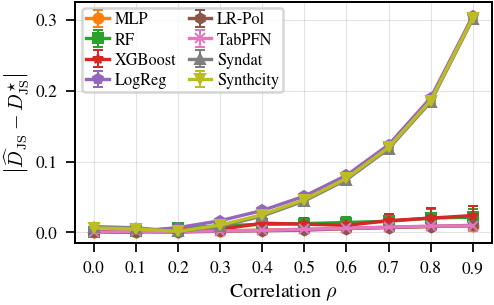

In [26]:
 
BASE_DIR = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")
USE_CASE, METHODS = "use_case_5", ["MLP", "RF", "XGBoost", "LogReg", "LogRegPol", "TabPFN"]
M, L, USE_CI_95 = 2000, 2000, False


def seeds_path(method, rho):
    return BASE_DIR / f"results_{method}" / USE_CASE / f"{float(rho):.1f}_{M}_{L}" / "seeds_js.csv"


def mean_and_error(values):
    values = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return values.mean(), 0.0

    std = values.std(ddof=1)
    err = 1.96 * std / np.sqrt(len(values)) if USE_CI_95 else std
    return values.mean(), err


def read_seed_df(method, rho):
    path = seeds_path(method, rho)
    return pd.read_csv(path) if path.exists() else None


def read_metric(method, rho, value_col, abs_error=True):
    df = read_seed_df(method, rho)
    if df is None or value_col not in df.columns:
        return None
    if abs_error and "Ground Truth MC JS" not in df.columns:
        return None

    values = (pd.to_numeric(df[value_col], errors="coerce") -
              pd.to_numeric(df["Ground Truth MC JS"], errors="coerce")).abs() if abs_error else df[value_col]

    mean, err = mean_and_error(values)
    return {"mean": mean, "err": err, "n": pd.to_numeric(values, errors="coerce").dropna().shape[0]}


def read_first_available(rho, value_col, abs_error=True):
    for method in METHODS:
        result = read_metric(method, rho, value_col, abs_error=abs_error)
        if result is not None:
            return result
    return None


def find_rhos():
    rhos = set()
    for method in METHODS:
        uc_dir = BASE_DIR / f"results_{method}" / USE_CASE
        if not uc_dir.exists():
            continue

        for p in uc_dir.glob(f"*_{M}_{L}/seeds_js.csv"):
            try:
                rhos.add(float(p.parent.name.split("_")[0]))
            except ValueError:
                pass

    rhos = sorted(rhos)
    if not rhos:
        raise RuntimeError("No se encontraron archivos seeds_js.csv para use_case_5.")
    return rhos


rows = []
for rho in find_rhos():
    gt = read_first_available(rho, "Ground Truth MC JS", abs_error=False)

    row = {
        "rho": rho,
        "GT MC JS mean": gt["mean"] if gt else np.nan,
        "GT MC JS err": gt["err"] if gt else np.nan,
    }

    for method in METHODS:
        result = read_metric(method, rho, "Disc JS", abs_error=True)
        row[f"{method} abs error mean"] = result["mean"] if result else np.nan
        row[f"{method} abs error err"] = result["err"] if result else np.nan

    for baseline, col in [("Syndat", "Syndat JS"), ("Synthcity", "Synthcity JS")]:
        result = read_first_available(rho, col, abs_error=True)
        row[f"{baseline} abs error mean"] = result["mean"] if result else np.nan
        row[f"{baseline} abs error err"] = result["err"] if result else np.nan

    rows.append(row)

uc5_df = pd.DataFrame(rows).sort_values("rho").reset_index(drop=True)
display(uc5_df)

color_map = {
    "MLP": "#ff7f0e", "RF": "#2ca02c", "XGBoost": "#d62728",
    "LogReg": "#9467bd", "LogRegPol": "#8c564b", "TabPFN": "#e377c2",
    "Syndat": "#7f7f7f", "Synthcity": "#bcbd22",
}

display_name = {
    "MLP": "MLP", "RF": "RF", "XGBoost": "XGBoost", "LogReg": "LogReg",
    "LogRegPol": "LR-Pol", "TabPFN": "TabPFN",
    "Syndat": "Syndat", "Synthcity": "Synthcity",
}

marker_map = {
    "MLP": "o", "RF": "s", "XGBoost": "*", "LogReg": "p",
    "LogRegPol": "h", "TabPFN": "x", "Syndat": "^", "Synthcity": "v",
}

style = {
    **bundles.icml2022(), "text.usetex": False, "font.size": 8,
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6.5, "legend.title_fontsize": 6.5,
    "axes.linewidth": 0.8, "grid.linewidth": 0.45,
    "figure.dpi": 180, "savefig.dpi": 300, "legend.frameon": True,
}
plt.rcParams.update(style)

fig, ax = plt.subplots(figsize=(2.8, 1.75), dpi=180)
x = uc5_df["rho"].to_numpy(dtype=float)

for method in METHODS + ["Syndat", "Synthcity"]:
    y_col, e_col = f"{method} abs error mean", f"{method} abs error err"
    if y_col not in uc5_df:
        continue

    y, e = uc5_df[y_col].to_numpy(dtype=float), uc5_df[e_col].to_numpy(dtype=float)
    if np.isnan(y).all():
        continue

    ax.errorbar(
        x, y, yerr=e, label=display_name.get(method, method),
        color=color_map.get(method, "#333333"), marker=marker_map.get(method, "o"),
        linestyle="-", linewidth=1.35, markersize=4.0, capsize=2,
        elinewidth=0.8, markeredgewidth=0.8,
    )

ax.set_xlabel(r"Correlation $\rho$", labelpad=1.5)
ax.set_ylabel(r"$\left|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}\right|$", labelpad=1.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{rho:.1f}" for rho in x])
ax.grid(True, alpha=0.35)

ax.legend(
    loc="upper left", bbox_to_anchor=(0.01, 0.99), ncols=2,
    frameon=True, handlelength=1.4, handletextpad=0.35,
    columnspacing=0.75, labelspacing=0.25, borderpad=0.25,
    borderaxespad=0.2,
)

plt.subplots_adjust(left=0.09, right=0.995, bottom=0.24, top=0.98)

out_dir = BASE_DIR / "results_discriminators" / USE_CASE / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "pdf"]:
    out_path = out_dir / f"marginal_vs_joint_distributions_paper_flat.{ext}"
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0.015, dpi=300)
    print(f"Figura guardada en: {out_path.resolve()}")

plt.show()
plt.close(fig)

### Absolute Jensen-Shannon estimation error across sample size and dependency shift

This figure summarizes two complementary sources of variability in empirical Jensen-Shannon divergence estimation. The left panel shows how the absolute estimation error changes with the training sample size \(N\), using the largest available values of \(M\) and \(L\). The right panel shows how the same error changes as the correlation parameter \(\rho\) modifies the dependency structure between variables. Error bars represent standard deviations across random seeds, or 95% confidence intervals if enabled.


=== UC3 absolute-error summary from seeds ===
     N  MLP abs error mean  MLP abs error err  MLP n_seeds  RF abs error mean  \
0   10            0.085856           0.062741            5           0.116046   
1   20            0.046817           0.045423            5           0.035786   
2   30            0.013407           0.008881            5           0.028389   
3   40            0.030603           0.017661            5           0.026740   
4   50            0.017235           0.013984            5           0.018058   
5   60            0.030539           0.026068            5           0.046931   
6   70            0.010595           0.008336            5           0.015078   
7   80            0.014598           0.012381            5           0.013832   
8   90            0.022445           0.011263            5           0.016456   
9  100            0.012420           0.006106            5           0.019815   

   RF abs error err  RF n_seeds  XGBoost abs error mean  \
0 

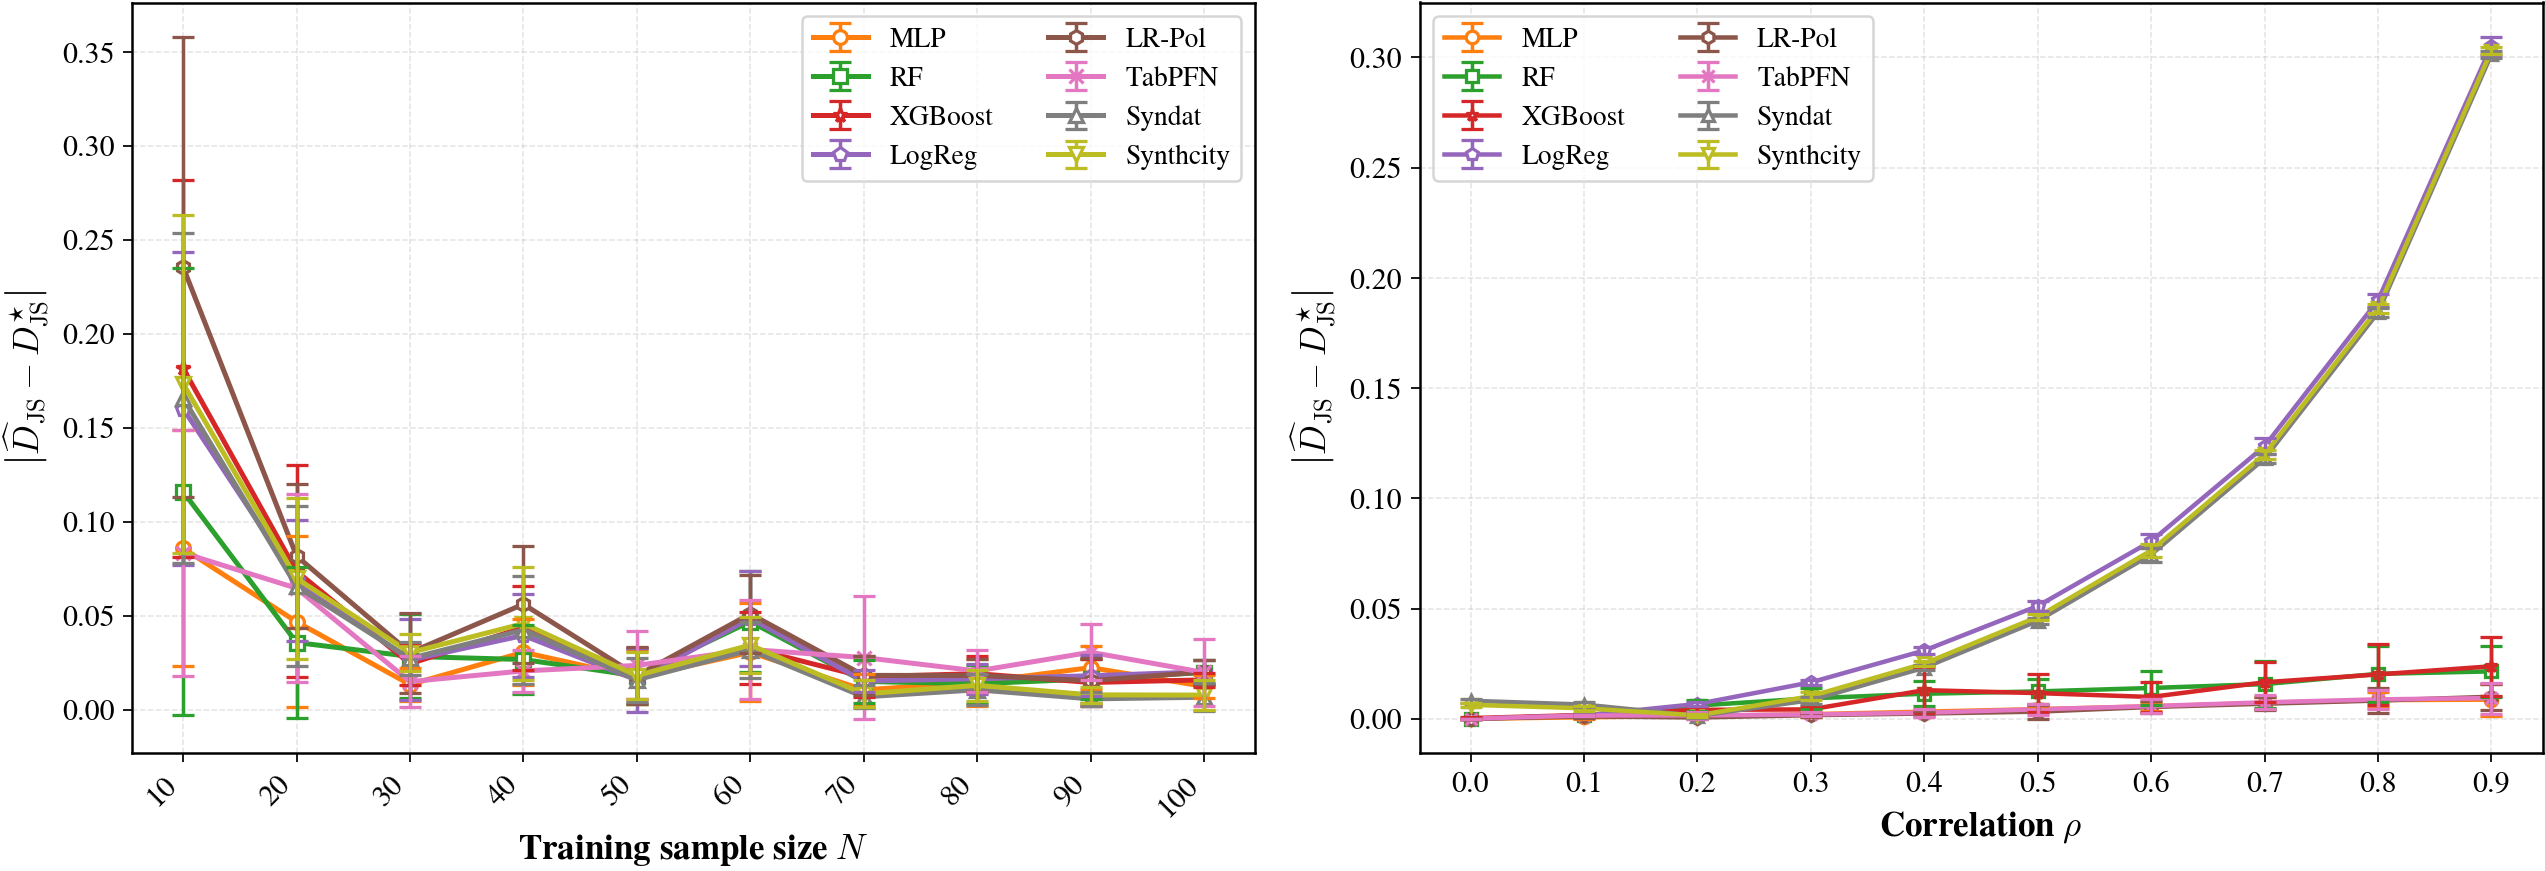

In [27]:
BASE_DIR = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")
CSV_UC3 = BASE_DIR / "results_discriminators" / "use_case_3" / "comparison_js.csv"

METHODS = ["MLP", "RF", "XGBoost", "LogReg", "LogRegPol", "TabPFN"]
BASELINES = ["Syndat", "Synthcity"]
M, L, USE_CI_95 = 2000, 2000, False

color_map = {
    "GT": "#1f77b4", "MLP": "#ff7f0e", "RF": "#2ca02c", "XGBoost": "#d62728",
    "LogReg": "#9467bd", "LogRegPol": "#8c564b", "TabPFN": "#e377c2",
    "Syndat": "#7f7f7f", "Synthcity": "#bcbd22",
}
display_name = {
    "MLP": "MLP", "RF": "RF", "XGBoost": "XGBoost", "LogReg": "LogReg",
    "LogRegPol": "LR-Pol", "TabPFN": "TabPFN", "Syndat": "Syndat", "Synthcity": "Synthcity",
}
marker_map = {
    "GT": "D", "MLP": "o", "RF": "s", "XGBoost": "*", "LogReg": "p",
    "LogRegPol": "h", "TabPFN": "x", "Syndat": "^", "Synthcity": "v",
}

style = {
    **bundles.icml2022(), "text.usetex": False, "font.size": 13,
    "axes.labelsize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 11, "axes.linewidth": 1.0, "grid.linewidth": 0.6,
    "figure.dpi": 180, "savefig.dpi": 300, "legend.frameon": True,
}
plt.rcParams.update(style)


def mean_and_error(values):
    values = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return values.mean(), 0.0

    std = values.std(ddof=1)
    err = 1.96 * std / np.sqrt(len(values)) if USE_CI_95 else std
    return values.mean(), err


def seeds_path(method, use_case, folder):
    return BASE_DIR / f"results_{method}" / use_case / folder / "seeds_js.csv"


def read_seed_df(method, use_case, folder):
    path = seeds_path(method, use_case, folder)
    return pd.read_csv(path) if path.exists() else None


def read_abs_error(method, use_case, folder, value_col):
    df = read_seed_df(method, use_case, folder)
    if df is None or value_col not in df.columns:
        return None

    gt_col = next((c for c in ["Ground Truth MC JS", "GT MC JS"] if c in df.columns), None)
    if gt_col is None:
        return None

    gt = pd.to_numeric(df[gt_col], errors="coerce")
    est = pd.to_numeric(df[value_col], errors="coerce")
    values = (est - gt).abs().dropna()

    mean, err = mean_and_error(values)
    return {"mean": mean, "err": err, "n": len(values)}


def read_first_available_abs_error(use_case, folder, value_col):
    for method in METHODS:
        result = read_abs_error(method, use_case, folder, value_col)
        if result is not None:
            return result
    return None


def add_result(row, name, result):
    row[f"{name} abs error mean"] = result["mean"] if result else np.nan
    row[f"{name} abs error err"] = result["err"] if result else np.nan
    row[f"{name} n_seeds"] = result["n"] if result else 0


def build_uc3_summary():
    assert CSV_UC3.exists(), f"No existe el archivo: {CSV_UC3.resolve()}"

    df = pd.read_csv(CSV_UC3).sort_values(["N", "M", "L"])
    m_ref, l_ref = int(df["M"].max()), int(df["L"].max())
    df_plot = df.query("M == @m_ref and L == @l_ref and N <= 100").sort_values("N")
    assert not df_plot.empty, "No hay filas para UC3 con el par (M, L) de referencia."

    rows = []
    for n in sorted(df_plot["N"].unique()):
        folder = f"{int(n)}_{m_ref}_{l_ref}"
        row = {"N": int(n)}

        for method in METHODS:
            add_result(row, method, read_abs_error(method, "use_case_3", folder, "Disc JS"))

        for baseline, col in [("Syndat", "Syndat JS"), ("Synthcity", "Synthcity JS")]:
            add_result(row, baseline, read_first_available_abs_error("use_case_3", folder, col))

        rows.append(row)

    return pd.DataFrame(rows).sort_values("N").reset_index(drop=True)


def find_uc5_rhos():
    rhos = set()
    for method in METHODS:
        uc_dir = BASE_DIR / f"results_{method}" / "use_case_5"
        if not uc_dir.exists():
            continue

        for p in uc_dir.glob(f"*_{M}_{L}/seeds_js.csv"):
            try:
                rhos.add(float(p.parent.name.split("_")[0]))
            except ValueError:
                pass

    rhos = sorted(rhos)
    if not rhos:
        raise RuntimeError("No se encontraron archivos seeds_js.csv para use_case_5.")
    return rhos


def build_uc5_summary():
    rows = []
    for rho in find_uc5_rhos():
        folder = f"{float(rho):.1f}_{M}_{L}"
        row = {"rho": rho}

        for method in METHODS:
            add_result(row, method, read_abs_error(method, "use_case_5", folder, "Disc JS"))

        for baseline, col in [("Syndat", "Syndat JS"), ("Synthcity", "Synthcity JS")]:
            add_result(row, baseline, read_first_available_abs_error("use_case_5", folder, col))

        rows.append(row)

    return pd.DataFrame(rows).sort_values("rho").reset_index(drop=True)


def plot_abs_error_panel(ax, df, x_col, xlabel, xtick_labels=None, linewidth=2.0, markersize=5.5):
    x = df[x_col].to_numpy(dtype=float)

    for method in METHODS + BASELINES:
        y_col, e_col = f"{method} abs error mean", f"{method} abs error err"
        if y_col not in df:
            continue

        y = df[y_col].to_numpy(dtype=float)
        e = np.where(np.isnan(df[e_col].to_numpy(dtype=float)), 0.0, df[e_col].to_numpy(dtype=float))

        if np.isnan(y).all():
            continue

        ax.errorbar(
            x, y, yerr=e, label=display_name.get(method, method),
            color=color_map.get(method, "#333333"), marker=marker_map.get(method, "o"),
            linestyle="-", linewidth=linewidth, markersize=markersize,
            markerfacecolor="white", markeredgewidth=1.3,
            capsize=4.5, capthick=1.4, elinewidth=1.4,
            barsabove=True, zorder=3,
        )

    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel(r"$\left|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}\right|$", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels if xtick_labels is not None else [str(int(v)) for v in x], rotation=45 if x_col == "N" else 0, ha="right" if x_col == "N" else "center")
    ax.grid(True, alpha=0.35, linestyle="--")
    ax.legend(loc="best", frameon=True, ncol=2)


uc3_summary = build_uc3_summary()
uc5_df = build_uc5_summary()

print("\n=== UC3 absolute-error summary from seeds ===")
print(uc3_summary)
print("\n=== UC5 absolute-error summary from seeds ===")
print(uc5_df)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14.5, 5.2), dpi=180)

plot_abs_error_panel(
    ax_l, uc3_summary, "N", "Training sample size $N$",
    xtick_labels=[str(int(n)) for n in uc3_summary["N"]],
    linewidth=2.0, markersize=5.5,
)

plot_abs_error_panel(
    ax_r, uc5_df, "rho", r"Correlation $\rho$",
    xtick_labels=[f"{rho:.1f}" for rho in uc5_df["rho"]],
    linewidth=1.8, markersize=5.0,
)

plt.tight_layout()

out_dir = BASE_DIR / "results_discriminators" / "combined_figures"
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "pdf"]:
    out_path = out_dir / f"marginals_and_finite.{ext}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Figura guardada en: {out_path.resolve()}")

plt.show()
plt.close(fig)

## Bloque 4: Tabla LaTeX con media y desviacion tipica (UC3)
Objetivo: verificar que los valores de `comparison_js.csv` son medias sobre semillas y exportar una tabla en LaTeX con formato `media ± std` para cada valor de `N`.

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np

uc3_comp_path = Path('results_discriminators/use_case_3/comparison_js.csv')
assert uc3_comp_path.exists(), f'No existe: {uc3_comp_path.resolve()}'

df = pd.read_csv(uc3_comp_path).sort_values(['N', 'M', 'L']).copy()

m_ref = int(df['M'].max())
l_ref = int(df['L'].max())

df_plot = df[(df['M'] == m_ref) & (df['L'] == l_ref)].sort_values('N').copy()
assert not df_plot.empty, 'No hay filas para el par (M, L) de referencia.'
 
df_plot = df_plot[df_plot['N'] <= 100].copy()
assert not df_plot.empty, 'No hay filas para el par (M, L) de referencia.'

gt_col = 'GT MC JS'
if gt_col not in df_plot.columns:
    # fallback por si el nombre del GT es distinto
    gt_candidates = [c for c in df_plot.columns if 'GT' in c and 'JS' in c]
    assert gt_candidates, 'No encuentro columna de GT JS.'
    gt_col = gt_candidates[0]

method_cols = [
    'Disc JS (MLP)',
    'Disc JS (RF)',
    'Disc JS (XGBoost)',
    'Disc JS (LogReg)',
    'Disc JS (LogRegPol)',
    'Disc JS (TabPFN)',
    'Syndat JS',
    'Synthcity JS',
]

method_cols = [c for c in method_cols if c in df_plot.columns]

pretty_names = {
    'Disc JS (MLP)': 'MLP',
    'Disc JS (RF)': 'RF',
    'Disc JS (XGBoost)': 'XGBoost',
    'Disc JS (LogReg)': 'LogReg',
    'Disc JS (LogRegPol)': 'LogRegPol',
    'Disc JS (TabPFN)': 'TabPFN',
    'Syndat JS': 'Syndat',
    'Synthcity JS': 'Synthcity',
}

out = {'N': df_plot['N'].astype(int)}

n_seeds = 5
z_975 = 1.959963984540054

ci_to_std = lambda ci: (
    pd.to_numeric(ci, errors='coerce') * np.sqrt(n_seeds) / z_975
)

method_sources = {
    'Disc JS (MLP)': ('results_MLP/use_case_3/js.csv', 'Disc JS (CI)'),
    'Disc JS (RF)': ('results_RF/use_case_3/js.csv', 'Disc JS (CI)'),
    'Disc JS (XGBoost)': ('results_XGBoost/use_case_3/js.csv', 'Disc JS (CI)'),
    'Disc JS (LogReg)': ('results_LogReg/use_case_3/js.csv', 'Disc JS (CI)'),
    'Disc JS (LogRegPol)': ('results_LogRegPol/use_case_3/js.csv', 'Disc JS (CI)'),
    'Disc JS (TabPFN)': ('results_TabPFN/use_case_3/js.csv', 'Disc JS (CI)'),
    'Syndat JS': ('results_MLP/use_case_3/js.csv', 'Syndat JS (CI)'),
    'Synthcity JS': ('results_MLP/use_case_3/js.csv', 'Synthcity JS (CI)'),
}

for col in method_cols:

    err = (
        pd.to_numeric(df_plot[col], errors='coerce') -
        pd.to_numeric(df_plot[gt_col], errors='coerce')
    ).abs()

    std = pd.Series(np.nan, index=df_plot.index)

    if col in method_sources:

        path_str, ci_name = method_sources[col]
        path = Path(path_str)

        if path.exists():

            aux = (
                pd.read_csv(path)
                .query("M == @m_ref and L == @l_ref")
                .sort_values("N")
            )

            aux = aux[aux["N"].isin(df_plot["N"])]

            if ci_name in aux.columns:

                std_vals = ci_to_std(aux[ci_name])

                std = (
                    pd.Series(std_vals.values, index=aux["N"])
                    .reindex(df_plot["N"])
                    .values
                )

    out[pretty_names.get(col, col)] = [
        (
            f"{100*e:.2f} $\\pm$ {100*s:.2f}"
            if pd.notna(e) and pd.notna(s)
            else (
                f"{100*e:.2f}"
                if pd.notna(e)
                else "--"
            )
        )
        for e, s in zip(err, std)
    ]

uc3_abs_error_table = pd.DataFrame(out)

time_source_map = {
    'MLP': ('results_MLP', 'Time (s)'),
    'RF': ('results_RF', 'Time (s)'),
    'XGBoost': ('results_XGBoost', 'Time (s)'),
    'LogReg': ('results_LogReg', 'Time (s)'),
    'LogRegPol': ('results_LogRegPol', 'Time (s)'),
    'TabPFN': ('results_TabPFN', 'Time (s)'),
    'Syndat': ('results_MLP', 'Syndat Time (s)'),
    'Synthcity': ('results_MLP', 'Synthcity Time (s)'),
}


def mean_time_for_method(method):
    source_dir, time_col = time_source_map.get(method, (None, None))
    if source_dir is None:
        return np.nan

    path = Path(f'{source_dir}/use_case_3/js.csv')
    if not path.exists() and source_dir == 'results_MLP':
        legacy = Path('results_MLP_cpu/use_case_3/js.csv')
        if legacy.exists():
            path = legacy

    if not path.exists():
        return np.nan

    frame = pd.read_csv(path).sort_values(['N', 'M', 'L']).copy()
    frame = frame[frame['N'].isin(df_plot['N'])].copy()
    if frame.empty or time_col not in frame.columns:
        return np.nan

    return pd.to_numeric(frame[time_col], errors='coerce').dropna().mean()


time_row = {'N': 'Time (s)'}
for method in method_cols:
    method_name = pretty_names.get(method, method)
    method_time = mean_time_for_method(method_name)
    time_row[method_name] = f"{method_time:.2f}" if pd.notna(method_time) else '--'

uc3_abs_error_table = pd.concat([uc3_abs_error_table, pd.DataFrame([time_row])], ignore_index=True)

display(uc3_abs_error_table)

latex_uc3 = uc3_abs_error_table.to_latex(
    index=False,
    escape=False,
    caption=(
        r'Use case 3: absolute estimation error with respect to the Monte Carlo reference, '
        r'$|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$, for the largest available '
        r'$M$ and $L$.'
    ),
    label='tab:uc3_abs_error_vs_gt',
    column_format='r' + 'c' * len(method_cols),
)

out_dir = Path('results_discriminators/use_case_3/tables')
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / 'uc3_abs_error_vs_gt.tex'
out_file.write_text(latex_uc3, encoding='utf-8')

print(latex_uc3)
print(f'Tabla LaTeX guardada en: {out_file.resolve()}')
print(f'Usando M = {m_ref} y L = {l_ref}')

,N,MLP,RF,XGBoost,LogReg,LogRegPol,TabPFN,Syndat,Synthcity
0,10,6.66 $\pm$ 12.15,11.10 $\pm$ 14.26,18.17 $\pm$ 5.68,16.02 $\pm$ 7.75,23.56 $\pm$ 1.36,5.37 $\pm$ 13.15,16.59 $\pm$ 4.26,17.35 $\pm$ 3.97
1,20,1.13 $\pm$ 8.38,8.80 $\pm$ 3.42,9.70 $\pm$ 3.72,9.43 $\pm$ 3.88,9.60 $\pm$ 3.63,7.44 $\pm$ 8.37,8.84 $\pm$ 2.55,9.08 $\pm$ 2.36
2,30,0.01 $\pm$ 0.91,4.22 $\pm$ 1.74,4.31 $\pm$ 0.80,4.75 $\pm$ 1.50,4.48 $\pm$ 0.78,1.99 $\pm$ 1.00,3.52 $\pm$ 0.64,3.73 $\pm$ 0.53
3,40,2.93 $\pm$ 3.70,6.73 $\pm$ 4.11,6.34 $\pm$ 2.07,6.77 $\pm$ 2.02,6.76 $\pm$ 1.35,4.59 $\pm$ 2.85,5.34 $\pm$ 1.15,5.52 $\pm$ 0.97
4,50,1.35 $\pm$ 2.95,3.06 $\pm$ 3.20,2.97 $\pm$ 1.93,3.22 $\pm$ 2.96,3.10 $\pm$ 2.81,1.67 $\pm$ 4.32,2.35 $\pm$ 1.03,2.53 $\pm$ 0.96
5,60,2.06 $\pm$ 2.27,4.79 $\pm$ 1.55,4.27 $\pm$ 1.15,4.66 $\pm$ 1.41,4.48 $\pm$ 0.94,1.68 $\pm$ 2.70,3.79 $\pm$ 0.69,4.06 $\pm$ 0.65
6,70,0.56 $\pm$ 1.61,2.18 $\pm$ 1.19,2.37 $\pm$ 0.94,2.16 $\pm$ 0.84,2.45 $\pm$ 0.83,1.13 $\pm$ 4.09,1.35 $\pm$ 0.60,1.51 $\pm$ 0.56
7,80,0.41 $\pm$ 2.15,2.64 $\pm$ 1.88,2.82 $\pm$ 1.11,2.65 $\pm$ 1.29,2.81 $\pm$ 1.40,1.43 $\pm$ 2.57,1.67 $\pm$ 0.50,1.85 $\pm$ 0.47
8,90,0.06 $\pm$ 2.37,1.94 $\pm$ 1.46,2.04 $\pm$ 1.23,2.00 $\pm$ 1.14,2.11 $\pm$ 0.93,0.69 $\pm$ 3.14,1.29 $\pm$ 0.54,1.47 $\pm$ 0.54
9,100,1.24 $\pm$ 1.10,5.02 $\pm$ 0.08,1.23 $\pm$ 0.56,1.71 $\pm$ 0.00,0.42 $\pm$ 0.01,12.58 $\pm$ 2.66,2.03 $\pm$ 0.34,1.61 $\pm$ 0.32


\begin{table}
\caption{Use case 3: absolute estimation error with respect to the Monte Carlo reference, $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$, for the largest available $M$ and $L$.}
\label{tab:uc3_abs_error_vs_gt}
\begin{tabular}{rcccccccc}
\toprule
N & MLP & RF & XGBoost & LogReg & LogRegPol & TabPFN & Syndat & Synthcity \\
\midrule
10 & 6.66 $\pm$ 12.15 & 11.10 $\pm$ 14.26 & 18.17 $\pm$ 5.68 & 16.02 $\pm$ 7.75 & 23.56 $\pm$ 1.36 & 5.37 $\pm$ 13.15 & 16.59 $\pm$ 4.26 & 17.35 $\pm$ 3.97 \\
20 & 1.13 $\pm$ 8.38 & 8.80 $\pm$ 3.42 & 9.70 $\pm$ 3.72 & 9.43 $\pm$ 3.88 & 9.60 $\pm$ 3.63 & 7.44 $\pm$ 8.37 & 8.84 $\pm$ 2.55 & 9.08 $\pm$ 2.36 \\
30 & 0.01 $\pm$ 0.91 & 4.22 $\pm$ 1.74 & 4.31 $\pm$ 0.80 & 4.75 $\pm$ 1.50 & 4.48 $\pm$ 0.78 & 1.99 $\pm$ 1.00 & 3.52 $\pm$ 0.64 & 3.73 $\pm$ 0.53 \\
40 & 2.93 $\pm$ 3.70 & 6.73 $\pm$ 4.11 & 6.34 $\pm$ 2.07 & 6.77 $\pm$ 2.02 & 6.76 $\pm$ 1.35 & 4.59 $\pm$ 2.85 & 5.34 $\pm$ 1.15 & 5.52 $\pm$ 0.97 \\
50 & 1.35 $\pm$ 2.95 & 3.06 $\pm$ 3.

## Auditoría de datos, tablas compactas, heatmaps y UC7 tiempo-scaling

Este bloque: 
2. Identifica los mejores clasificadores por UC
3. Genera tablas compactas (solo top 3 métodos)
4. Crea heatmaps de error absoluto
5. Genera figura de líneas para UC7: tiempo vs dimensionalidad

Dimensiones encontradas: [2, 10, 25, 40, 50]
Dimensión máxima: 50


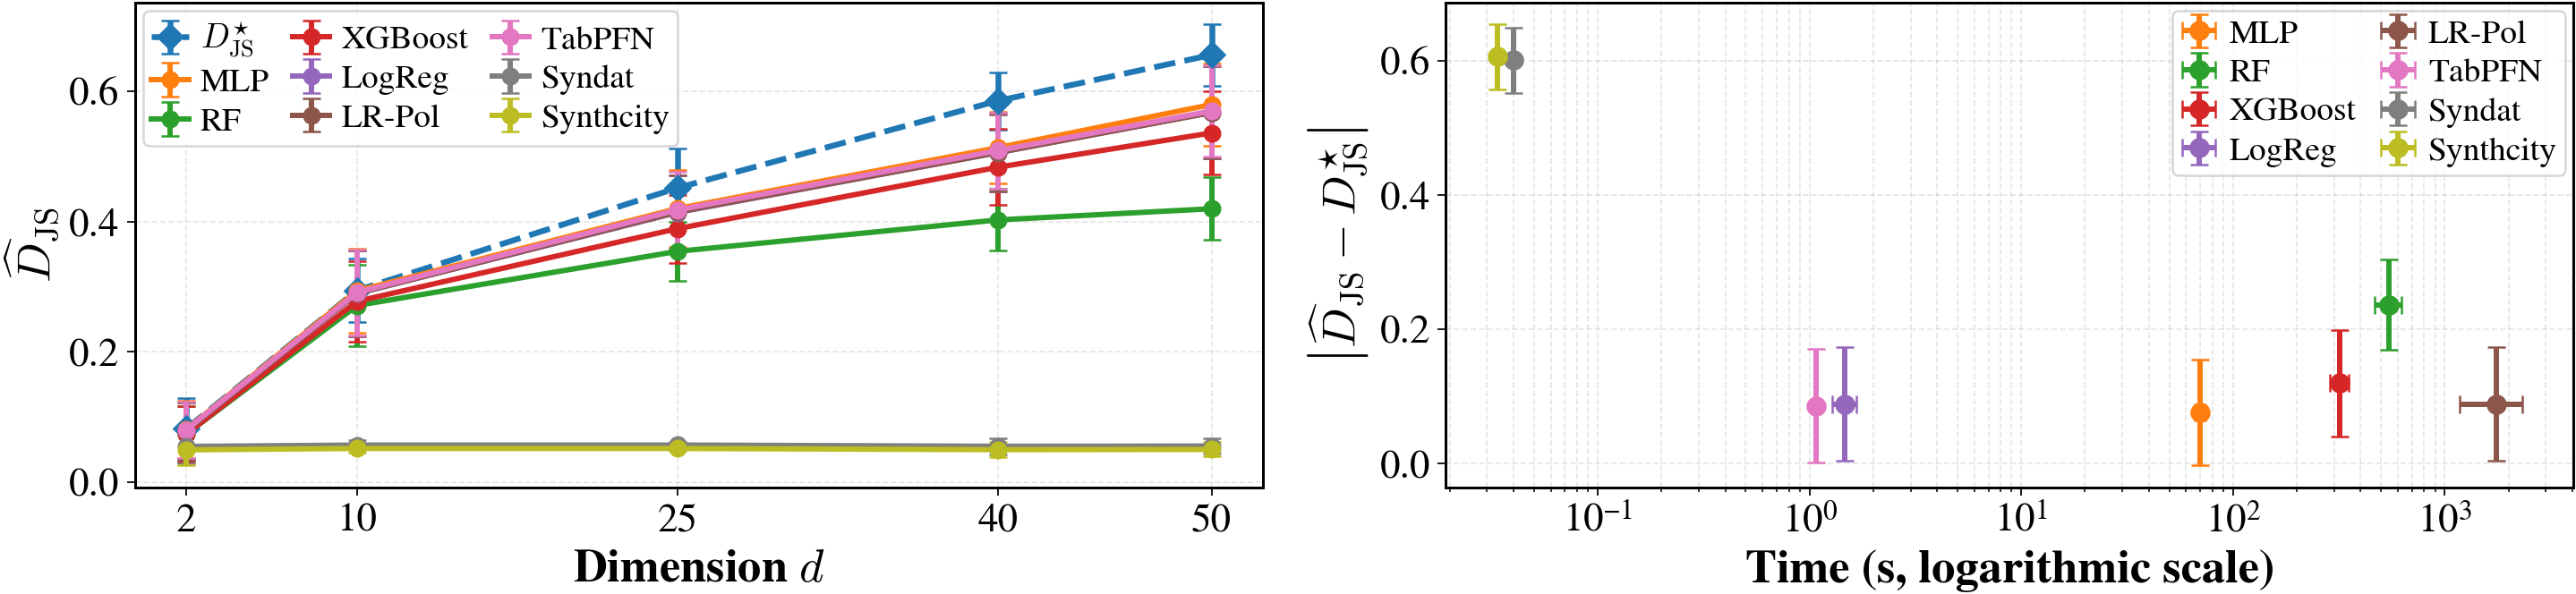

Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_7/figures/dimensionality_paper.png
Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_7/figures/jdimensionality_paper.pdf


In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles

# =========================
# CONFIG
# =========================
BASE_DIR = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")

USE_CASE = "use_case_7"

METHODS = ["MLP", "RF", "XGBoost", "LogReg", "LogRegPol", "TabPFN"]

# Si quieres intervalo de confianza 95%, deja True.
# Si prefieres barras de desviación estándar, pon False.
USE_CI_95 = False

# Carpetas tipo:
# results_LogReg/use_case_7/2_2000_2000/seeds_js.csv
def seeds_path(method, dim):
    return BASE_DIR / f"results_{method}" / USE_CASE / f"{dim}_2000_2000" / "seeds_js.csv"


# =========================
# FIND DIMENSIONS
# =========================
dims = set()

for method in METHODS:
    uc_dir = BASE_DIR / f"results_{method}" / USE_CASE
    if not uc_dir.exists():
        continue

    for p in uc_dir.glob("*_2000_2000/seeds_js.csv"):
        dim = int(p.parent.name.split("_")[0])
        dims.add(dim)

dims = sorted(dims)

if not dims:
    raise RuntimeError("No se encontraron archivos seeds_js.csv para use_case_7.")

max_dim = max(dims)

print("Dimensiones encontradas:", dims)
print("Dimensión máxima:", max_dim)


# =========================
# HELPERS
# =========================
def mean_and_error(values):
    values = pd.to_numeric(values, errors="coerce").dropna().to_numpy()

    if len(values) == 0:
        return np.nan, np.nan

    mean = np.mean(values)

    if len(values) == 1:
        return mean, 0.0

    std = np.std(values, ddof=1)

    if USE_CI_95:
        err = 1.96 * std / np.sqrt(len(values))
    else:
        err = std

    return mean, err


def read_metric(method, dim, value_col, time_col=None):
    path = seeds_path(method, dim)

    if not path.exists():
        return None

    df = pd.read_csv(path)

    if value_col not in df.columns:
        return None

    value_mean, value_err = mean_and_error(df[value_col])

    result = {
        "mean": value_mean,
        "err": value_err,
        "n": df[value_col].dropna().shape[0],
    }

    if time_col is not None and time_col in df.columns:
        time_mean, time_err = mean_and_error(df[time_col])
        result["time_mean"] = time_mean
        result["time_err"] = time_err

    return result


def read_first_available(dim, value_col, time_col=None):
    """
    Para Ground Truth, Syndat y Synthcity, que aparecen dentro de los CSV
    de cada estimador, usamos el primer archivo existente para esa dimensión.
    """
    for method in METHODS:
        result = read_metric(method, dim, value_col, time_col)
        if result is not None:
            return result

    return None


# =========================
# BUILD SUMMARY TABLE
# =========================
rows = []

for dim in dims:
    # Ground Truth
    gt = read_first_available(dim, "Ground Truth MC JS")

    row = {
        "N": dim,
        "GT MC JS mean": gt["mean"] if gt else np.nan,
        "GT MC JS err": gt["err"] if gt else np.nan,
    }

    # Discriminator estimators
    for method in METHODS:
        result = read_metric(method, dim, "Disc JS", "Time (s)")

        row[f"{method} JS mean"] = result["mean"] if result else np.nan
        row[f"{method} JS err"] = result["err"] if result else np.nan
        row[f"{method} Time mean"] = result.get("time_mean", np.nan) if result else np.nan
        row[f"{method} Time err"] = result.get("time_err", np.nan) if result else np.nan

    # Syndat and Synthcity
    syndat = read_first_available(dim, "Syndat JS", "Syndat Time (s)")
    synthcity = read_first_available(dim, "Synthcity JS", "Synthcity Time (s)")

    row["Syndat JS mean"] = syndat["mean"] if syndat else np.nan
    row["Syndat JS err"] = syndat["err"] if syndat else np.nan
    row["Syndat Time mean"] = syndat.get("time_mean", np.nan) if syndat else np.nan
    row["Syndat Time err"] = syndat.get("time_err", np.nan) if syndat else np.nan

    row["Synthcity JS mean"] = synthcity["mean"] if synthcity else np.nan
    row["Synthcity JS err"] = synthcity["err"] if synthcity else np.nan
    row["Synthcity Time mean"] = synthcity.get("time_mean", np.nan) if synthcity else np.nan
    row["Synthcity Time err"] = synthcity.get("time_err", np.nan) if synthcity else np.nan

    rows.append(row)

uc7_df = pd.DataFrame(rows).sort_values("N").reset_index(drop=True)


# =========================
# COLOR MAP
# =========================
color_map_uc7 = {
    "GT MC JS": "#1f77b4",
    "MLP": "#ff7f0e",
    "RF": "#2ca02c",
    "XGBoost": "#d62728",
    "LogReg": "#9467bd",
    "LogRegPol": "#8c564b",
    "TabPFN": "#e377c2",
    "Syndat": "#7f7f7f",
    "Synthcity": "#bcbd22",
}

plot_methods = METHODS + ["Syndat", "Synthcity"]

plot_methods = METHODS + ["Syndat", "Synthcity"]

display_name = {
    "MLP": "MLP",
    "RF": "RF",
    "XGBoost": "XGBoost",
    "LogReg": "LogReg",
    "LogRegPol": "LR-Pol",
    "TabPFN": "TabPFN",
    "Syndat": "Syndat",
    "Synthcity": "Synthcity",
}
# =========================
# =========================
# STYLE
# =========================
style = {
    **bundles.icml2022(),
    "text.usetex": False,
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 18,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.7,
    "figure.dpi": 180,
    "savefig.dpi": 300,
}

plt.rcParams.update(style)


# =========================
# FIGURE
# =========================
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16.5, 4.2), dpi=180) 

dims = uc7_df["N"].astype(int).to_numpy()


# =========================
# LEFT: JS vs DIMENSION
# =========================
y_gt = uc7_df["GT MC JS mean"].to_numpy()
e_gt = uc7_df["GT MC JS err"].to_numpy()

if not np.isnan(y_gt).all():
    ax_l.errorbar(
        dims,
        y_gt,
        yerr=e_gt,
        label=r"$D_{\mathrm{JS}}^{\star}$",
        color=color_map_uc7["GT MC JS"],
        marker="D",
        linestyle="--",
        linewidth=2.6,
        markersize=8,
        capsize=4,
    )

for method in plot_methods:
    y_col = f"{method} JS mean"
    e_col = f"{method} JS err"

    if y_col not in uc7_df.columns:
        continue

    y = uc7_df[y_col].to_numpy()
    e = uc7_df[e_col].to_numpy()

    if np.isnan(y).all():
        continue

    ax_l.errorbar(
        dims,
        y,
        yerr=e,
        label=display_name.get(method, method),
        color=color_map_uc7.get(method, "#333333"),
        marker="o",
        linestyle="-",
        linewidth=2.4,
        markersize=7,
        capsize=4,
    )

ax_l.set_xlabel("Dimension $d$", fontweight="bold")
ax_l.set_ylabel(r"$\widehat{D}_{\mathrm{JS}}$", fontweight="bold")

ax_l.set_xticks(dims)
ax_l.set_xticklabels([str(d) for d in dims])

ax_l.grid(True, alpha=0.3, linestyle="--")
ax_l.legend(
    loc="upper left",
    frameon=True,
    ncol=3,
    handlelength=1.1,
    handletextpad=0.35,
    columnspacing=0.7,
    labelspacing=0.25,
    borderpad=0.25,
    borderaxespad=0.25,
)


# =========================
# RIGHT: TIME vs JS
# ONLY HIGHEST DIMENSION
# =========================
row_max = uc7_df.loc[uc7_df["N"] == max_dim].iloc[0]

gt_mean_max = row_max["GT MC JS mean"]
gt_err_max = row_max["GT MC JS err"]

for method in plot_methods:
    js_mean_col = f"{method} JS mean"
    js_err_col = f"{method} JS err"
    time_mean_col = f"{method} Time mean"
    time_err_col = f"{method} Time err"

    if js_mean_col not in uc7_df.columns or time_mean_col not in uc7_df.columns:
        continue

    x = row_max[time_mean_col]
    xerr = row_max[time_err_col]

    # Absolute error with respect to Monte Carlo ground truth
    y = abs(row_max[js_mean_col] - gt_mean_max)

    # Approximate propagated uncertainty
    yerr = np.sqrt(row_max[js_err_col]**2 + gt_err_max**2)

    if pd.isna(x) or pd.isna(y):
        continue

    ax_r.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        label=display_name.get(method, method),
        color=color_map_uc7.get(method, "#333333"),
        marker="o",
        linestyle="None",
        linewidth=2.4,
        markersize=8,
        capsize=4,
    )
 
ax_r.set_xlabel("Time (s, logarithmic scale)", fontweight="bold")
ax_r.set_ylabel(r"$\left|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}\right|$", fontweight="bold") 

# Tiempo en escala logarítmica
ax_r.set_xscale("log")

ax_r.grid(True, alpha=0.3, linestyle="--", which="both")
ax_r.legend(
    loc="upper right",
    frameon=True,
    ncol=2,
    handlelength=1.1,
    handletextpad=0.35,
    columnspacing=0.7,
    labelspacing=0.25,
    borderpad=0.25,
    borderaxespad=0.25,
)


plt.tight_layout()


# =========================
# SAVE
# =========================
out_dir = BASE_DIR / "results_discriminators" / USE_CASE / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

suffix = "ci95" if USE_CI_95 else "std"

out_png = out_dir / f"dimensionality_paper.png"
out_pdf = out_dir / f"jdimensionality_paper.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Figura guardada en: {out_png.resolve()}")
print(f"Figura guardada en: {out_pdf.resolve()}")

#TABLES

##REAL CASE: Tabla  UC4 (adult + intrusion) con columna N
Objetivo: generar tablas para **VAE** y **CTGAN** con formato similar a UC4 (columnas por clasificador), incorporando la columna **N** para reportar los distintos tamanos de entrenamiento (`train_100`, `train_50`, `train_25`, `train_12_5`).

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
BASE = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")
OUT_BASE = BASE / "results_discriminators" / "use_case_11"

DATASETS = ["adult", "intrusion"]
GENERATORS = ["vae", "ctgan"]

DISC_METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN"]

METHODS = ["MLP", "RF", "LogReg", "XGBoost", "LogRegPol", "TabPFN", "Syndat", "Synthcity"]

TRAIN_CONFIG = {
    "train_100": {
        "caption": (
            "Use case 4 for adult and intrusion with VAE and CTGAN. "
            "Rows report mean $\\pm$ standard deviation over seeds for "
            "$\\widehat{D}_{\\mathrm{JS}}$ and runtime."
        ),
        "latex_label": "tab:uc4_adult_intrusion_vae_ctgan_mean_std_split",
        "filename": "uc4_adult_intrusion_vae_ctgan_train100_mean_std_split.tex",
    },
    "train_50": {
        "caption": (
            "Use case 12 for adult and intrusion with VAE and CTGAN. "
            "Rows report mean $\\pm$ standard deviation over seeds for "
            "$\\widehat{D}_{\\mathrm{JS}}$ and runtime."
        ),
        "latex_label": "tab:uc12_adult_intrusion_vae_ctgan_mean_std_split",
        "filename": "uc12_adult_intrusion_vae_ctgan_train50_mean_std_split.tex",
    },
}


# =========================
# PATH HELPERS
# =========================
def find_uc4_seeds_path(method, dataset, generator):
    base_dir = BASE / f"results_{method}" / "use_case_4" / dataset / generator
    path = base_dir / "10000_7500_1000" / "seeds_js.csv"

    if path.exists():
        return path

    candidates = sorted(base_dir.glob("*/seeds_js.csv")) if base_dir.exists() else []
    return candidates[-1] if candidates else None


def find_uc12_seeds_path(method, dataset, generator):
    base_dir = BASE / f"results_{method}" / "use_case_12" / dataset / generator

    preferred_paths = [
        base_dir / "-_3750_500" / "seeds_js.csv",
        base_dir / "None_3750_500" / "seeds_js.csv",
        base_dir / "reduced_3750_500" / "seeds_js.csv",
        base_dir / "3750_500" / "seeds_js.csv",
    ]

    for path in preferred_paths:
        if path.exists():
            return path

    candidates = sorted(base_dir.glob("*_3750_500/seeds_js.csv")) if base_dir.exists() else []
    return candidates[0] if candidates else None


def find_seeds_path(method, dataset, generator, train_frac):
    if train_frac == "train_100":
        return find_uc4_seeds_path(method, dataset, generator)

    if train_frac == "train_50":
        return find_uc12_seeds_path(method, dataset, generator)

    return None


def find_first_available_seeds_path(dataset, generator, train_frac):
    for method in DISC_METHODS:
        path = find_seeds_path(method, dataset, generator, train_frac)
        if path is not None and path.exists():
            return path

    return None


# =========================
# STATS HELPERS
# =========================
def mean_std_from_seeds(path, column):
    if path is None or not path.exists():
        return np.nan, np.nan

    df = pd.read_csv(path, na_values=["-", ""])

    if column not in df.columns:
        return np.nan, np.nan

    values = pd.to_numeric(df[column], errors="coerce").dropna().to_numpy(dtype=float)

    if len(values) == 0:
        return np.nan, np.nan

    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0

    return mean, std


def fmt_mean_std(mean, std, digits):
    if pd.isna(mean):
        return "-"

    if pd.isna(std):
        return f"{mean:.{digits}f}"

    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def get_method_columns(method):
    if method in DISC_METHODS:
        return "Disc JS", "Time (s)"

    if method == "Syndat":
        return "Syndat JS", "Syndat Time (s)"

    if method == "Synthcity":
        return "Synthcity JS", "Synthcity Time (s)"

    return None, None


def get_method_stats(method, dataset, generator, train_frac):
    if method in DISC_METHODS:
        path = find_seeds_path(method, dataset, generator, train_frac)
    else:
        path = find_first_available_seeds_path(dataset, generator, train_frac)

    djs_col, time_col = get_method_columns(method)

    djs_mean, djs_std = mean_std_from_seeds(path, djs_col)
    time_mean, time_std = mean_std_from_seeds(path, time_col)

    return djs_mean, djs_std, time_mean, time_std


# =========================
# TABLE BUILDERS
# =========================
def build_rows_for_train(train_frac):
    djs_rows = []
    time_rows = []

    for generator in GENERATORS:
        for dataset in DATASETS:
            djs_row = {
                "Generator": generator.upper(),
                "Dataset": dataset,
            }

            time_row = {
                "Generator": generator.upper(),
                "Dataset": dataset,
            }

            for method in METHODS:
                djs_mean, djs_std, time_mean, time_std = get_method_stats(
                    method=method,
                    dataset=dataset,
                    generator=generator,
                    train_frac=train_frac,
                )

                djs_row[method] = fmt_mean_std(djs_mean, djs_std, digits=2)
                time_row[method] = fmt_mean_std(time_mean, time_std, digits=2)


            djs_rows.append(djs_row)
            time_rows.append(time_row)

    return djs_rows, time_rows


def rows_to_latex(rows):
    lines = []

    for row in rows:
        values = [row["Generator"], row["Dataset"]] + [row[m] for m in METHODS]
        lines.append(" & ".join(values) + r" \\")

    return "\n".join(lines)


def latex_table_split(train_frac):
    cfg = TRAIN_CONFIG[train_frac]

    djs_rows, time_rows = build_rows_for_train(train_frac)

    n_cols = 2 + len(METHODS)
    column_format = "ll" + "r" * len(METHODS)

    header = "Generator & Dataset & " + " & ".join(METHODS) + r" \\"

    djs_body = rows_to_latex(djs_rows)
    time_body = rows_to_latex(time_rows)

    djs_section = (
        r"\multicolumn{"
        + str(n_cols)
        + r"}{c}{\textbf{$\widehat{D}_{\mathrm{JS}}$}} \\"
    )

    time_section = (
        r"\multicolumn{"
        + str(n_cols)
        + r"}{c}{\textbf{Time (s)}} \\"
    )

    latex = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\scriptsize\n"
        "\\setlength{\\tabcolsep}{2.2pt}\n"
        f"\\caption{{{cfg['caption']}}}\n"
        f"\\label{{{cfg['latex_label']}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{column_format}}}\n"
        "\\toprule\n"
        f"{header}\n"
        "\\midrule\n"
        f"{djs_section}\n"
        "\\midrule\n"
        f"{djs_body}\n"
        "\\midrule\n"
        f"{time_section}\n"
        "\\midrule\n"
        f"{time_body}\n"
        "\\bottomrule\n"
        "\\end{tabular}%\n"
        "}\n"
        "\\end{table}"
    )

    djs_table = pd.DataFrame(djs_rows)[["Generator", "Dataset"] + METHODS]
    time_table = pd.DataFrame(time_rows)[["Generator", "Dataset"] + METHODS]

    return djs_table, time_table, latex



# =========================
# SAVE TWO TABLES
# =========================
out_dir = OUT_BASE / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

for train_frac in ["train_100", "train_50"]:
    djs_table, time_table, latex = latex_table_split(train_frac)

    out_path = out_dir / TRAIN_CONFIG[train_frac]["filename"]
    out_path.write_text(latex, encoding="utf-8")

    print("\n" + "=" * 80)
    print(train_frac)
    print("=" * 80)
    print(latex)
    print(f"Guardado en: {out_path.resolve()}")

    print("\nDJS")
    display(djs_table)

    print("\nTime")
    display(time_table)



train_100
\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.2pt}
\caption{Use case 4 for adult and intrusion with VAE and CTGAN. Rows report mean $\pm$ standard deviation over seeds for $\widehat{D}_{\mathrm{JS}}$ and runtime.}
\label{tab:uc4_adult_intrusion_vae_ctgan_mean_std_split}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrrrr}
\toprule
Generator & Dataset & MLP & RF & LogReg & XGBoost & LogRegPol & TabPFN & Syndat & Synthcity \\
\midrule
\multicolumn{10}{c}{\textbf{$\widehat{D}_{\mathrm{JS}}$}} \\
\midrule
VAE & adult & 0.19 $\pm$ 0.01 & 0.21 $\pm$ 0.01 & 0.03 $\pm$ 0.00 & 0.69 $\pm$ 0.03 & 0.05 $\pm$ 0.00 & 0.41 $\pm$ 0.01 & 0.01 $\pm$ 0.00 & 0.01 $\pm$ 0.00 \\
VAE & intrusion & 0.92 $\pm$ 0.01 & 0.99 $\pm$ 0.01 & 0.05 $\pm$ 0.01 & 1.00 $\pm$ 0.00 & 0.22 $\pm$ 0.01 & 0.99 $\pm$ 0.00 & 0.04 $\pm$ 0.00 & 0.02 $\pm$ 0.00 \\
CTGAN & adult & 0.12 $\pm$ 0.01 & 0.17 $\pm$ 0.02 & 0.02 $\pm$ 0.01 & 0.67 $\pm$ 0.01 & 0.04 $\pm$ 0.01 & 0.38 $\pm$ 0.02 & 0.01 $\pm$ 0.

,Generator,Dataset,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,VAE,adult,0.19 $\pm$ 0.01,0.21 $\pm$ 0.01,0.03 $\pm$ 0.00,0.69 $\pm$ 0.03,0.05 $\pm$ 0.00,0.41 $\pm$ 0.01,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,0.92 $\pm$ 0.01,0.99 $\pm$ 0.01,0.05 $\pm$ 0.01,1.00 $\pm$ 0.00,0.22 $\pm$ 0.01,0.99 $\pm$ 0.00,0.04 $\pm$ 0.00,0.02 $\pm$ 0.00
2,CTGAN,adult,0.12 $\pm$ 0.01,0.17 $\pm$ 0.02,0.02 $\pm$ 0.01,0.67 $\pm$ 0.01,0.04 $\pm$ 0.01,0.38 $\pm$ 0.02,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,0.56 $\pm$ 0.03,0.84 $\pm$ 0.01,0.07 $\pm$ 0.01,0.90 $\pm$ 0.01,0.29 $\pm$ 0.01,0.83 $\pm$ 0.01,0.02 $\pm$ 0.00,0.01 $\pm$ 0.00



Time


,Generator,Dataset,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,VAE,adult,932.60 $\pm$ 384.28,425.61 $\pm$ 30.67,54.80 $\pm$ 3.56,158.24 $\pm$ 12.15,3733.98 $\pm$ 145.06,1.55 $\pm$ 0.38,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,1122.72 $\pm$ 97.16,311.83 $\pm$ 11.69,864.81 $\pm$ 111.77,136.01 $\pm$ 5.52,25275.99 $\pm$ 899.58,1.73 $\pm$ 0.17,0.04 $\pm$ 0.00,0.03 $\pm$ 0.00
2,CTGAN,adult,955.84 $\pm$ 210.48,402.26 $\pm$ 17.76,50.42 $\pm$ 0.91,151.99 $\pm$ 14.44,3423.97 $\pm$ 180.47,1.45 $\pm$ 0.16,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,1163.12 $\pm$ 200.03,296.91 $\pm$ 19.55,734.26 $\pm$ 35.02,164.56 $\pm$ 6.98,28076.65 $\pm$ 420.86,1.76 $\pm$ 0.37,0.04 $\pm$ 0.00,0.03 $\pm$ 0.00



train_50
\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.2pt}
\caption{Use case 12 for adult and intrusion with VAE and CTGAN. Rows report mean $\pm$ standard deviation over seeds for $\widehat{D}_{\mathrm{JS}}$ and runtime.}
\label{tab:uc12_adult_intrusion_vae_ctgan_mean_std_split}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrrrr}
\toprule
Generator & Dataset & MLP & RF & LogReg & XGBoost & LogRegPol & TabPFN & Syndat & Synthcity \\
\midrule
\multicolumn{10}{c}{\textbf{$\widehat{D}_{\mathrm{JS}}$}} \\
\midrule
VAE & adult & 0.17 $\pm$ 0.01 & 0.18 $\pm$ 0.02 & 0.03 $\pm$ 0.01 & 0.64 $\pm$ 0.02 & 0.06 $\pm$ 0.01 & 0.41 $\pm$ 0.02 & 0.01 $\pm$ 0.00 & 0.01 $\pm$ 0.00 \\
VAE & intrusion & 0.85 $\pm$ 0.02 & 0.97 $\pm$ 0.02 & 0.00 $\pm$ 0.00 & 0.99 $\pm$ 0.01 & 0.06 $\pm$ 0.01 & 0.99 $\pm$ 0.00 & 0.04 $\pm$ 0.00 & 0.02 $\pm$ 0.00 \\
CTGAN & adult & 0.11 $\pm$ 0.02 & 0.16 $\pm$ 0.02 & 0.03 $\pm$ 0.01 & 0.60 $\pm$ 0.03 & 0.05 $\pm$ 0.01 & 0.38 $\pm$ 0.02 & 0.01 $\pm$ 0

,Generator,Dataset,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,VAE,adult,0.17 $\pm$ 0.01,0.18 $\pm$ 0.02,0.03 $\pm$ 0.01,0.64 $\pm$ 0.02,0.06 $\pm$ 0.01,0.41 $\pm$ 0.02,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,0.85 $\pm$ 0.02,0.97 $\pm$ 0.02,0.00 $\pm$ 0.00,0.99 $\pm$ 0.01,0.06 $\pm$ 0.01,0.99 $\pm$ 0.00,0.04 $\pm$ 0.00,0.02 $\pm$ 0.00
2,CTGAN,adult,0.11 $\pm$ 0.02,0.16 $\pm$ 0.02,0.03 $\pm$ 0.01,0.60 $\pm$ 0.03,0.05 $\pm$ 0.01,0.38 $\pm$ 0.02,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,0.54 $\pm$ 0.05,0.79 $\pm$ 0.01,0.04 $\pm$ 0.01,0.89 $\pm$ 0.02,0.13 $\pm$ 0.01,0.83 $\pm$ 0.01,0.02 $\pm$ 0.00,0.01 $\pm$ 0.00



Time


,Generator,Dataset,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,VAE,adult,330.33 $\pm$ 184.94,245.33 $\pm$ 11.54,46.52 $\pm$ 1.99,110.20 $\pm$ 3.72,4697.13 $\pm$ 71.08,0.90 $\pm$ 0.22,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,293.53 $\pm$ 150.94,191.25 $\pm$ 17.57,501.94 $\pm$ 83.89,93.08 $\pm$ 2.45,12380.26 $\pm$ 559.56,1.12 $\pm$ 0.40,0.03 $\pm$ 0.00,0.03 $\pm$ 0.00
2,CTGAN,adult,331.53 $\pm$ 180.42,243.81 $\pm$ 11.54,44.73 $\pm$ 0.99,114.87 $\pm$ 8.41,4581.41 $\pm$ 504.60,0.85 $\pm$ 0.14,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,534.86 $\pm$ 100.99,206.07 $\pm$ 7.64,558.28 $\pm$ 78.96,107.99 $\pm$ 6.96,14161.09 $\pm$ 715.48,0.93 $\pm$ 0.03,0.03 $\pm$ 0.00,0.03 $\pm$ 0.00


# uc13

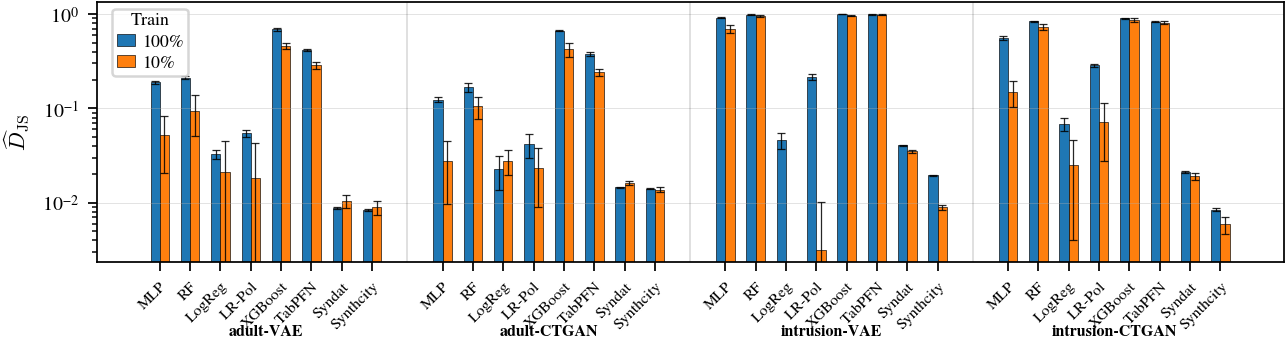

Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_11/figures/uc11_djs_train100_train10_log_flat_from_seeds_std.png
Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_11/figures/uc11_djs_train100_train10_log_flat_from_seeds_std.pdf


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles

# =========================
# CONFIG
# =========================
BASE = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")

UC11_BASE = BASE / "results_discriminators" / "use_case_11"

DATASETS = ["adult", "intrusion"]
GENERATORS = ["vae", "ctgan"]

DISC_METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN"]
METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN", "Syndat", "Synthcity"]

TRAIN_ORDER = ["train_100", "train_10"]

TRAIN_LABELS = {
    "train_100": "100%",
    "train_10": "10%",
}

TRAIN_COLORS = {
    "train_100": "#1f77b4",
    "train_10": "#ff7f0e",
}

# =========================
# STYLE WITH TUEPLOTS
# =========================
plt.rcParams.update({
    **bundles.icml2022(),
    "text.usetex": False,
    "figure.figsize": (7.2, 1.95),  # más achatada
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 6.3,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.2,
    "legend.title_fontsize": 7.2,

    "axes.linewidth": 0.7,
    "grid.linewidth": 0.4,
    "legend.frameon": True,
})

# =========================
# HELPERS
# =========================
def find_uc4_seeds_path(method, dataset, generator):
    base_dir = BASE / f"results_{method}" / "use_case_4" / dataset / generator
    path = base_dir / "10000_7500_1000" / "seeds_js.csv"

    if path.exists():
        return path

    candidates = sorted(base_dir.glob("*/seeds_js.csv")) if base_dir.exists() else []
    return candidates[-1] if candidates else None


def find_uc14_seeds_path(method, dataset, generator):
    base_dir = BASE / f"results_{method}" / "use_case_14" / dataset / generator

    preferred_paths = [
        base_dir / "750_100" / "seeds_js.csv",
    ]

    for path in preferred_paths:
        if path.exists():
            return path

    candidates = sorted(base_dir.glob("*_750_100/seeds_js.csv")) if base_dir.exists() else []
    return candidates[0] if candidates else None


def find_seeds_path(method, dataset, generator, train_frac):
    if train_frac == "train_100":
        return find_uc4_seeds_path(method, dataset, generator)

    if train_frac == "train_10":
        return find_uc14_seeds_path(method, dataset, generator)

    return None


def find_first_available_seeds_path(dataset, generator, train_frac):
    for method in DISC_METHODS:
        path = find_seeds_path(method, dataset, generator, train_frac)
        if path is not None and path.exists():
            return path

    return None


def mean_std_from_seeds(path, column):
    if path is None or not path.exists():
        return np.nan, np.nan

    df = pd.read_csv(path, na_values=["-", ""])

    if column not in df.columns:
        return np.nan, np.nan

    values = pd.to_numeric(df[column], errors="coerce").dropna().to_numpy(dtype=float)

    if len(values) == 0:
        return np.nan, np.nan

    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0

    return mean, std


def get_method_stats(method, dataset, generator, train_frac):
    if method in DISC_METHODS:
        path = find_seeds_path(method, dataset, generator, train_frac)
        column = "Disc JS"

    elif method == "Syndat":
        path = find_first_available_seeds_path(dataset, generator, train_frac)
        column = "Syndat JS"

    elif method == "Synthcity":
        path = find_first_available_seeds_path(dataset, generator, train_frac)
        column = "Synthcity JS"

    else:
        return np.nan, np.nan

    return mean_std_from_seeds(path, column)


# =========================
# BUILD DATA
# =========================
records = []

for dataset in DATASETS:
    for generator in GENERATORS:
        for train_frac in TRAIN_ORDER:
            for method in METHODS:
                mean, std = get_method_stats(method, dataset, generator, train_frac)

                if pd.isna(mean):
                    print(
                        f"[WARN] Missing value: dataset={dataset}, generator={generator}, "
                        f"train={train_frac}, method={method}"
                    )
                    continue

                records.append({
                    "Dataset": dataset,
                    "Generator": generator.upper(),
                    "Train": train_frac,
                    "Method": method,
                    "DJS_mean": mean,
                    "DJS_std": std,
                })

plot_df = pd.DataFrame(records)
assert not plot_df.empty, "No se han encontrado datos para pintar."

METHOD_LABELS = {
    "LogRegPol": "LR-Pol",
}


# =========================
# PLOT
# =========================
blocks = [
    ("adult", "VAE"),
    ("adult", "CTGAN"),
    ("intrusion", "VAE"),
    ("intrusion", "CTGAN"),
]

bar_width = 0.22
method_gap = 0.72
block_gap = 0.95

fig, ax = plt.subplots()

xticks = []
xticklabels = []
block_centers = []
current_x = 0.0

for dataset, generator in blocks:
    block_start = current_x

    for method_idx, method in enumerate(METHODS):
        method_center = current_x

        xticks.append(method_center)
        xticklabels.append(METHOD_LABELS.get(method, method))

        for train_idx, train_frac in enumerate(TRAIN_ORDER):
            offset = (train_idx - 0.5) * bar_width

            subset = plot_df[
                (plot_df["Dataset"] == dataset)
                & (plot_df["Generator"] == generator)
                & (plot_df["Method"] == method)
                & (plot_df["Train"] == train_frac)
            ]

            if subset.empty:
                continue

            y = float(subset["DJS_mean"].iloc[0])
            yerr = float(subset["DJS_std"].iloc[0])

            if y <= 0:
                continue

            ax.bar(
                method_center + offset,
                y,
                yerr=yerr,
                width=bar_width,
                color=TRAIN_COLORS[train_frac],
                label=TRAIN_LABELS[train_frac] if (dataset, generator, method_idx) == ("adult", "VAE", 0) else None,
                edgecolor="black",
                linewidth=0.25,
                capsize=1.5,
                error_kw={
                    "elinewidth": 0.5,
                    "capthick": 0.5,
                    "alpha": 0.85,
                },
            )

        current_x += method_gap

    block_end = current_x - method_gap
    block_centers.append(((block_start + block_end) / 2, f"{dataset}-{generator}"))
    current_x += block_gap

# =========================
# AXES
# =========================
ax.set_yscale("log")
ax.set_ylabel(r"$\widehat{D}_{\mathrm{JS}}$")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha="right", rotation_mode="anchor")

for center, label in block_centers:
    ax.text(
        center,
        -0.24,
        label,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=6.4,
        fontweight="bold",
    )

for i in range(1, len(block_centers)):
    sep_x = (block_centers[i - 1][0] + block_centers[i][0]) / 2
    ax.axvline(sep_x, color="black", alpha=0.16, linewidth=0.6)

# Leyenda dentro de la figura para no añadir altura extra.
ax.legend(
    title="Train",
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncols=1,
    frameon=True,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.2,
)

ax.grid(True, axis="y", alpha=0.35)
ax.grid(False, axis="x")

# Menos margen vertical. El bottom sigue dejando sitio a métodos + bloques.
plt.subplots_adjust(bottom=0.29, top=0.97, left=0.07, right=0.995)

# =========================
# SAVE
# =========================
out_dir = UC11_BASE / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / "uc11_djs_train100_train10_log_flat_from_seeds_std.png"
out_pdf = out_dir / "uc11_djs_train100_train10_log_flat_from_seeds_std.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.015)
fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.015)

plt.show()
plt.close(fig)

print(f"Figura guardada en: {out_png.resolve()}")
print(f"Figura guardada en: {out_pdf.resolve()}")


In [32]:
# tablas

In [33]:
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

BASE = Path('.')
N_SEEDS = 5
Z_975 = 1.959963984540054

RESULT_ORDER = [
    ('Disc JS (MLP)', 'MLP'),
    ('Disc JS (RF)', 'RF'),
    ('Disc JS (LogReg)', 'LogReg'),
    ('Disc JS (XGBoost)', 'XGBoost'),
    ('Disc JS (LogRegPol)', 'LogRegPol'),
    ('Disc JS (TabPFN)', 'TabPFN'),
    ('Syndat JS', 'Syndat'),
    ('Synthcity JS', 'Synthcity'),
]

TIME_ORDER = [
    ('Time (MLP)', 'MLP'),
    ('Time (RF)', 'RF'),
    ('Time (LogReg)', 'LogReg'),
    ('Time (XGBoost)', 'XGBoost'),
    ('Time (LogRegPol)', 'LogRegPol'),
    ('Time (TabPFN)', 'TabPFN'),
    ('Syndat Time (s)', 'Syndat'),
    ('Synthcity Time (s)', 'Synthcity'),
]

DISPLAY_ORDER = [label for _, label in RESULT_ORDER]

METHOD_TO_RESULTS_DIR = {
    'MLP': 'results_MLP',
    'RF': 'results_RF',
    'LogReg': 'results_LogReg',
    'XGBoost': 'results_XGBoost',
    'LogRegPol': 'results_LogRegPol',
    'TabPFN': 'results_TabPFN',
    'Syndat': 'results_MLP',
    'Synthcity': 'results_MLP',
}


def _find_gt_column(frame: pd.DataFrame) -> str:
    candidates = [column for column in frame.columns if 'GT' in column and 'JS' in column]
    if 'GT MC JS' in frame.columns:
        return 'GT MC JS'
    if candidates:
        return candidates[0]
    raise ValueError('No GT JS column found.')


def _pick_row(frame: pd.DataFrame, label_col: str, value) -> pd.Series:
    numeric_values = pd.to_numeric(frame[label_col], errors='coerce')
    matches = frame[np.isclose(numeric_values, float(value))]
    if matches.empty:
        raise ValueError(f'No row found for {label_col}={value}.')
    return matches.iloc[0]


def _latex_table(body: pd.DataFrame, column_format: str, caption: str, label: str) -> str:
    tabular = body.to_latex(index=False, escape=False, column_format=column_format)
    return (
        '\\begin{table}[ht]\n'
        '\\centering\n'
        '\\small\n'
        '\\setlength{\\tabcolsep}{3pt}\n'
        f'\\caption{{{caption}}}\n'
        f'\\label{{{label}}}\n'
        f'{tabular}'
        '\\end{table}'
    )


@lru_cache(maxsize=None)
def _read_csv_cached(path_str: str) -> pd.DataFrame:
    return pd.read_csv(path_str)


def _ci_to_std(ci_value) -> float:
    ci = pd.to_numeric(pd.Series([ci_value]), errors='coerce').iloc[0]
    if pd.isna(ci):
        return np.nan
    return float(ci) * np.sqrt(N_SEEDS) / Z_975


def _fmt_mean_std(mean_value, std_value, mean_decimals: int, std_decimals: int) -> str:
    mean = pd.to_numeric(pd.Series([mean_value]), errors='coerce').iloc[0]
    std = pd.to_numeric(pd.Series([std_value]), errors='coerce').iloc[0]

    if pd.isna(mean):
        return '-'
    if pd.isna(std):
        return f'{float(mean):.{mean_decimals}f} $\\pm$ --'

    return f'{float(mean):.{mean_decimals}f} $\\pm$ {float(std):.{std_decimals}f}'


def _extract_std_from_ci(row: pd.Series, ci_col_candidates) -> float:
    if row is None:
        return np.nan

    for ci_col in ci_col_candidates:
        if ci_col in row.index:
            return _ci_to_std(row[ci_col])

    return np.nan


def _extract_method_js_std(row: pd.Series, method_label: str) -> float:
    if method_label in {'MLP', 'RF', 'LogReg', 'XGBoost', 'LogRegPol', 'TabPFN'}:
        return _extract_std_from_ci(row, ['Disc JS (CI)'])

    if method_label == 'Syndat':
        return _extract_std_from_ci(row, ['Syndat JS (CI)'])

    if method_label == 'Synthcity':
        return _extract_std_from_ci(row, ['Synthcity JS (CI)'])

    return np.nan


def _extract_gt_std(row: pd.Series) -> float:
    return _extract_std_from_ci(row, ['Ground Truth MC JS (CI)', 'MC JS (CI)'])


def _extract_time_std(row: pd.Series, method_label: str) -> float:
    if method_label in {'MLP', 'RF', 'LogReg', 'XGBoost', 'LogRegPol', 'TabPFN'}:
        return _extract_std_from_ci(row, ['Time (s) (CI)', 'Time (CI)', 'Disc Time (CI)'])

    if method_label == 'Syndat':
        return _extract_std_from_ci(row, ['Syndat Time (s) (CI)', 'Syndat Time (CI)'])

    if method_label == 'Synthcity':
        return _extract_std_from_ci(row, ['Synthcity Time (s) (CI)', 'Synthcity Time (CI)'])

    return np.nan


def _load_js_row_for_value(method_label: str, case_parts: tuple[str, ...], label_col: str, value):
    results_dir = METHOD_TO_RESULTS_DIR.get(method_label)
    if results_dir is None:
        return None

    js_path = BASE / results_dir / Path(*case_parts) / 'js.csv'

    if not js_path.exists():
        return None

    frame = _read_csv_cached(str(js_path))

    try:
        return _pick_row(frame, label_col, value)
    except Exception:
        return None


def _format_abs_error_table(
    frame: pd.DataFrame,
    label_col: str,
    selected_values,
    case_parts: tuple[str, ...],
    mode_value: str | None = None,
    label_formatter=None,
) -> pd.DataFrame:
    subset = frame.copy()
    gt_col = _find_gt_column(subset)
    rows = []

    for value in selected_values:
        row = _pick_row(subset, label_col, value)
        row_data = {}

        if mode_value is not None:
            row_data['Mode'] = mode_value

        row_data[label_col] = label_formatter(value) if label_formatter is not None else f'{value:g}'

        for source_col, display_col in RESULT_ORDER:
            if source_col not in subset.columns:
                continue

            mean_abs_err = abs(float(row[source_col]) - float(row[gt_col]))
            js_row = _load_js_row_for_value(display_col, case_parts, label_col, value)

            if js_row is None:
                std_abs_err = np.nan
            else:
                method_std = _extract_method_js_std(js_row, display_col)
                gt_std = _extract_gt_std(js_row)

                if pd.isna(method_std) and pd.isna(gt_std):
                    std_abs_err = np.nan
                elif pd.isna(method_std):
                    std_abs_err = gt_std
                elif pd.isna(gt_std):
                    std_abs_err = method_std
                else:
                    std_abs_err = float(np.sqrt(method_std ** 2 + gt_std ** 2))

            row_data[display_col] = _fmt_mean_std(
                mean_abs_err,
                std_abs_err,
                mean_decimals=4,
                std_decimals=4,
            )

        rows.append(row_data)

    time_row = {}

    if mode_value is not None:
        time_row['Mode'] = mode_value

    time_row[label_col] = 'Time (avg s)'

    for source_col, display_col in TIME_ORDER:
        if source_col not in subset.columns:
            continue

        mean_time = pd.to_numeric(subset[source_col], errors='coerce').mean()
        std_candidates = []

        for value in selected_values:
            js_row = _load_js_row_for_value(display_col, case_parts, label_col, value)

            if js_row is None:
                continue

            std_time_seed = _extract_time_std(js_row, display_col)

            if not pd.isna(std_time_seed):
                std_candidates.append(std_time_seed)

        avg_std_time = float(np.mean(std_candidates)) if std_candidates else np.nan

        time_row[display_col] = _fmt_mean_std(
            mean_time,
            avg_std_time,
            mean_decimals=2,
            std_decimals=2,
        )

    rows.append(time_row)

    return pd.DataFrame(rows)


In [34]:
# UC5: absolute errors with mean +- std (std from seed CI)

uc5_path = BASE / 'results_discriminators' / 'use_case_5' / 'comparison_js.csv'
uc5 = pd.read_csv(uc5_path).sort_values(['N', 'M', 'L']).copy()

uc5_selected = [0.0, 0.5, 0.7, 0.9]

uc5_table = _format_abs_error_table(
    uc5,
    'N',
    uc5_selected,
    case_parts=('use_case_5',),
    label_formatter=lambda value: f'{float(value):.1f}',
)

uc5_caption = (
    r'Use case 5. Absolute Jensen--Shannon estimation error for representative values of $\rho$, '
    r'reported as mean $\pm$ std over 5 seeds. The GT column is omitted, so every classifier-based '
    r'estimate and baseline is shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$.'
)

uc5_latex = _latex_table(
    uc5_table,
    'r' + 'c' * len(DISPLAY_ORDER),
    uc5_caption,
    'tab:uc5_abs_error_no_gt_mean_std',
)

uc5_out_dir = BASE / 'results_discriminators' / 'use_case_5' / 'tables'
uc5_out_dir.mkdir(parents=True, exist_ok=True)

uc5_out_file = uc5_out_dir / 'uc5_abs_error_no_gt_mean_std.tex'
uc5_out_file.write_text(uc5_latex, encoding='utf-8')

print(uc5_latex)
print(f'Guardado en: {uc5_out_file.resolve()}')

display(uc5_table)

\begin{table}[ht]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Use case 5. Absolute Jensen--Shannon estimation error for representative values of $\rho$, reported as mean $\pm$ std over 5 seeds. The GT column is omitted, so every classifier-based estimate and baseline is shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$.}
\label{tab:uc5_abs_error_no_gt_mean_std}
\begin{tabular}{rcccccccc}
\toprule
N & MLP & RF & LogReg & XGBoost & LogRegPol & TabPFN & Syndat & Synthcity \\
\midrule
0.0 & 0.0000 $\pm$ 0.0000 & 0.0000 $\pm$ 0.0001 & 0.0000 $\pm$ 0.0000 & 0.0003 $\pm$ 0.0004 & 0.0000 $\pm$ 0.0000 & 0.0001 $\pm$ 0.0001 & 0.0082 $\pm$ 0.0007 & 0.0063 $\pm$ 0.0009 \\
0.5 & 0.0008 $\pm$ 0.0046 & 0.0124 $\pm$ 0.0054 & 0.0512 $\pm$ 0.0019 & 0.0117 $\pm$ 0.0077 & 0.0022 $\pm$ 0.0039 & 0.0002 $\pm$ 0.0049 & 0.0444 $\pm$ 0.0010 & 0.0463 $\pm$ 0.0011 \\
0.7 & 0.0012 $\pm$ 0.0076 & 0.0157 $\pm$ 0.0097 & 0.1237 $\pm$ 0.0029 & 0.0166 $\pm$ 0.0081 & 0.0007 $\pm$ 0.0075 & 0.0017

,N,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,0.0,0.0000 $\pm$ 0.0000,0.0000 $\pm$ 0.0001,0.0000 $\pm$ 0.0000,0.0003 $\pm$ 0.0004,0.0000 $\pm$ 0.0000,0.0001 $\pm$ 0.0001,0.0082 $\pm$ 0.0007,0.0063 $\pm$ 0.0009
1,0.5,0.0008 $\pm$ 0.0046,0.0124 $\pm$ 0.0054,0.0512 $\pm$ 0.0019,0.0117 $\pm$ 0.0077,0.0022 $\pm$ 0.0039,0.0002 $\pm$ 0.0049,0.0444 $\pm$ 0.0010,0.0463 $\pm$ 0.0011
2,0.7,0.0012 $\pm$ 0.0076,0.0157 $\pm$ 0.0097,0.1237 $\pm$ 0.0029,0.0166 $\pm$ 0.0081,0.0007 $\pm$ 0.0075,0.0017 $\pm$ 0.0079,0.1181 $\pm$ 0.0018,0.1200 $\pm$ 0.0015
3,0.9,0.0030 $\pm$ 0.0102,0.0215 $\pm$ 0.0104,0.3054 $\pm$ 0.0036,0.0238 $\pm$ 0.0119,0.0019 $\pm$ 0.0110,0.0031 $\pm$ 0.0107,0.3015 $\pm$ 0.0012,0.3031 $\pm$ 0.0012
4,Time (avg s),94.02 $\pm$ --,181.76 $\pm$ --,0.31 $\pm$ --,73.46 $\pm$ --,31.73 $\pm$ --,0.45 $\pm$ --,0.01 $\pm$ --,0.01 $\pm$ --


# uc7

In [35]:
# UC7: absolute errors across dimensionalities, with a min/max runtime row

from pathlib import Path
import numpy as np
import pandas as pd

uc7_selected = [2, 10, 25, 40, 50]
methods = ["MLP", "RF", "LogReg", "XGBoost", "LogRegPol", "TabPFN", "Syndat", "Synthcity"]
disc_methods = ["MLP", "RF", "LogReg", "XGBoost", "LogRegPol", "TabPFN"]
method_to_column = {
    "MLP": ("Disc JS", "Time (s)"),
    "RF": ("Disc JS", "Time (s)"),
    "LogReg": ("Disc JS", "Time (s)"),
    "XGBoost": ("Disc JS", "Time (s)"),
    "LogRegPol": ("Disc JS", "Time (s)"),
    "TabPFN": ("Disc JS", "Time (s)"),
    "Syndat": ("Syndat JS", "Syndat Time (s)"),
    "Synthcity": ("Synthcity JS", "Synthcity Time (s)"),
}


def seeds_path(method, dim):
    return BASE / f"results_{method}" / "use_case_7" / f"{dim}_2000_2000" / "seeds_js.csv"


def first_available_seeds_path(dim):
    for method in disc_methods:
        path = seeds_path(method, dim)
        if path.exists():
            return path
    return None


def mean_std(values):
    values = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    return mean, std


def load_seed_frame(method, dim):
    if method in disc_methods:
        path = seeds_path(method, dim)
    else:
        path = first_available_seeds_path(dim)

    if path is None or not path.exists():
        return None

    return pd.read_csv(path)


rows = []
for dim in uc7_selected:
    row = {"N": str(int(dim))}
    for method in methods:
        frame = load_seed_frame(method, dim)
        value_col, time_col = method_to_column[method]

        if frame is None or value_col not in frame.columns or "Ground Truth MC JS" not in frame.columns:
            row[method] = "-"
            continue

        abs_error = 100.0 * (pd.to_numeric(frame[value_col], errors="coerce") - pd.to_numeric(frame["Ground Truth MC JS"], errors="coerce")).abs()
        mean, std = mean_std(abs_error)
        row[method] = f"{mean:.2f} $\\pm$ {std:.2f}"

    rows.append(row)

runtime_row = {"N": "Time [min,max] (s)"}
min_dim = min(uc7_selected)
max_dim = max(uc7_selected)

for method in methods:
    frame_min = load_seed_frame(method, min_dim)
    frame_max = load_seed_frame(method, max_dim)
    _, time_col = method_to_column[method]

    if frame_min is None or frame_max is None or time_col not in frame_min.columns or time_col not in frame_max.columns:
        runtime_row[method] = "-"
        continue

    min_time = pd.to_numeric(frame_min[time_col], errors="coerce").dropna().mean()
    max_time = pd.to_numeric(frame_max[time_col], errors="coerce").dropna().mean()
    runtime_row[method] = f"[{min_time:.2f}, {max_time:.2f}]"

rows.append(runtime_row)

uc7_table = pd.DataFrame(rows, columns=["N"] + methods)

uc7_caption = (
    r'Absolute Jensen-Shannon estimation error across dimensionalities, reported as mean $\pm$ std over 5 seeds. '
    r'All divergence values are multiplied by 100 and shown with two decimals. The last row reports runtime as '
    r'$[\min, \max]$ over the smallest and largest tested dimensions. Reported times correspond to a single '
    r'representative run and include the full training pipeline, including model fitting and hyperparameter search '
    r'when enabled.'
)

uc7_latex = _latex_table(
    uc7_table,
    'r' + 'c' * len(methods),
    uc7_caption,
    'tab:uc7_abs_error_no_gt_mean_std_x100_2dec_time_range',
)

uc7_out_dir = BASE / 'results_discriminators' / 'use_case_7' / 'tables'
uc7_out_dir.mkdir(parents=True, exist_ok=True)

uc7_out_file = uc7_out_dir / 'uc7_abs_error_no_gt_mean_std_x100_2dec_time_range.tex'
uc7_out_file.write_text(uc7_latex, encoding='utf-8')

print(uc7_latex)
print(f'Guardado en: {uc7_out_file.resolve()}')

display(uc7_table)


\begin{table}[ht]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Absolute Jensen-Shannon estimation error across dimensionalities, reported as mean $\pm$ std over 5 seeds. All divergence values are multiplied by 100 and shown with two decimals. The last row reports runtime as $[\min, \max]$ over the smallest and largest tested dimensions. Reported times correspond to a single representative run and include the full training pipeline, including model fitting and hyperparameter search when enabled.}
\label{tab:uc7_abs_error_no_gt_mean_std_x100_2dec_time_range}
\begin{tabular}{rcccccccc}
\toprule
N & MLP & RF & LogReg & XGBoost & LogRegPol & TabPFN & Syndat & Synthcity \\
\midrule
2 & 0.52 $\pm$ 0.35 & 0.82 $\pm$ 0.60 & 0.56 $\pm$ 0.42 & 0.83 $\pm$ 0.78 & 0.57 $\pm$ 0.43 & 0.61 $\pm$ 0.43 & 3.15 $\pm$ 1.52 & 3.59 $\pm$ 1.80 \\
10 & 1.38 $\pm$ 0.89 & 2.33 $\pm$ 1.89 & 1.45 $\pm$ 1.22 & 1.91 $\pm$ 1.20 & 1.44 $\pm$ 1.21 & 1.69 $\pm$ 1.07 & 23.75 $\pm$ 4.30 & 24.28 $\pm$ 4.33 \\
25 &

,N,MLP,RF,LogReg,XGBoost,LogRegPol,TabPFN,Syndat,Synthcity
0,2,0.52 $\pm$ 0.35,0.82 $\pm$ 0.60,0.56 $\pm$ 0.42,0.83 $\pm$ 0.78,0.57 $\pm$ 0.43,0.61 $\pm$ 0.43,3.15 $\pm$ 1.52,3.59 $\pm$ 1.80
1,10,1.38 $\pm$ 0.89,2.33 $\pm$ 1.89,1.45 $\pm$ 1.22,1.91 $\pm$ 1.20,1.44 $\pm$ 1.21,1.69 $\pm$ 1.07,23.75 $\pm$ 4.30,24.28 $\pm$ 4.33
2,25,3.16 $\pm$ 0.61,9.73 $\pm$ 1.70,3.77 $\pm$ 0.91,6.25 $\pm$ 1.14,3.70 $\pm$ 0.90,3.37 $\pm$ 0.76,39.46 $\pm$ 5.99,39.99 $\pm$ 5.98
3,40,7.19 $\pm$ 1.63,18.28 $\pm$ 1.10,7.94 $\pm$ 1.89,10.19 $\pm$ 1.61,7.94 $\pm$ 1.89,7.64 $\pm$ 1.80,53.02 $\pm$ 4.09,53.54 $\pm$ 4.10
4,50,7.62 $\pm$ 2.44,23.61 $\pm$ 1.69,8.84 $\pm$ 2.86,11.97 $\pm$ 2.27,8.85 $\pm$ 2.86,8.62 $\pm$ 2.75,60.03 $\pm$ 4.17,60.56 $\pm$ 4.20
5,"Time [min,max] (s)","[64.99, 69.91]","[160.28, 545.74]","[0.44, 1.47]","[71.52, 317.88]","[32.17, 1754.08]","[0.55, 1.08]","[0.00, 0.04]","[0.00, 0.03]"


# uc6

In [36]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
BASE = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")

METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN", "Syndat", "Synthcity"]
DISC_METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN"]

DISPLAY_ORDER = METHODS

UC6_SELECTED = [0.1, 0.5, 1.0]
GAPS = [0.3, 0.7, 1.0]

UC6_MODES = [
    ("Correction OFF", "use_case_13/OFF"),
    ("Correction ON", "use_case_13/ON"),
]

UC6_OUT_DIR = BASE / "results_discriminators" / "use_case_13" / "tables"
UC6_OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# HELPERS
# =========================
def n_folder(n):
    return f"{float(n):.1f}_2000_2000"


def gap_folder(gap):
    return f"gap_{float(gap):.1f}"


def seeds_path(method, use_case_name, gap, n):
    return (
        BASE
        / f"results_{method}"
        / use_case_name
        / gap_folder(gap)
        / n_folder(n)
        / "seeds_js.csv"
    )


def first_available_seeds_path(use_case_name, gap, n):
    """
    Syndat y Synthcity suelen venir repetidos en los seeds_js.csv
    de cada estimador. Usamos el primero disponible.
    """
    for method in DISC_METHODS:
        path = seeds_path(method, use_case_name, gap, n)
        if path.exists():
            return path

    return None


def method_columns(method):
    if method in DISC_METHODS:
        return "Disc JS", "Time (s)"

    if method == "Syndat":
        return "Syndat JS", "Syndat Time (s)"

    if method == "Synthcity":
        return "Synthcity JS", "Synthcity Time (s)"

    return None, None


def read_seed_values(path, column):
    if path is None or not path.exists():
        return np.asarray([], dtype=float)

    df = pd.read_csv(path, na_values=["-", ""])

    if column not in df.columns:
        return np.asarray([], dtype=float)

    return pd.to_numeric(df[column], errors="coerce").dropna().to_numpy(dtype=float)


def mean_std(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0

    return mean, std


def fmt_mean_std(mean, std, digits=4):
    if pd.isna(mean):
        return "-"

    if pd.isna(std):
        return f"{mean:.{digits}f}"

    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def get_stats(method, use_case_name, gap, n):
    if method in DISC_METHODS:
        path = seeds_path(method, use_case_name, gap, n)
    else:
        path = first_available_seeds_path(use_case_name, gap, n)

    js_col, time_col = method_columns(method)

    gt = read_seed_values(path, "Ground Truth MC JS")
    est = read_seed_values(path, js_col)
    time_values = read_seed_values(path, time_col)

    min_len = min(len(gt), len(est))

    if min_len == 0:
        abs_err_mean, abs_err_std = np.nan, np.nan
    else:
        abs_err = np.abs(est[:min_len] - gt[:min_len])
        abs_err_mean, abs_err_std = mean_std(abs_err)

    time_mean, time_std = mean_std(time_values)

    return abs_err_mean, abs_err_std, time_mean, time_std


def latex_table(body, column_format, caption, label):
    tabular = body.to_latex(index=False, escape=False, column_format=column_format)

    return (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\scriptsize\n"
        "\\setlength{\\tabcolsep}{2.5pt}\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        f"{tabular}"
        "\\end{table}"
    )


# =========================
# BUILD TABLES
# =========================
for gap in GAPS:
    rows = []

    for mode_label, use_case_name in UC6_MODES:
        for n in UC6_SELECTED:
            row = {
                "Mode": mode_label,
                "N": f"{float(n):.1f}",
            }

            for method in METHODS:
                err_mean, err_std, _, _ = get_stats(
                    method=method,
                    use_case_name=use_case_name,
                    gap=gap,
                    n=n,
                )

                row[method] = fmt_mean_std(err_mean, err_std, digits=4)

            rows.append(row)

        time_row = {
            "Mode": mode_label,
            "N": "Time (s)",
        }

        for method in METHODS:
            _, _, time_mean, time_std = get_stats(
                method=method,
                use_case_name=use_case_name,
                gap=gap,
                n=UC6_SELECTED[-1],
            )

            time_row[method] = fmt_mean_std(time_mean, time_std, digits=2)

        rows.append(time_row)

    uc6_table = pd.DataFrame(rows)
    uc6_table = uc6_table[["Mode", "N"] + DISPLAY_ORDER]

    uc6_caption = (
        rf"Use case 6. Absolute Jensen--Shannon estimation error for gap magnitude ${gap:.1f}$, "
        r"with and without prior correction, reported as mean $\pm$ std over seeds. "
        r"Values are shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; "
        r"the final row in each mode reports mean runtime."
    )

    uc6_label = f"tab:uc6_gap_{str(gap).replace('.', 'p')}_on_off_mean_std_from_seeds"

    uc6_latex = latex_table(
        uc6_table,
        "lr" + "c" * len(DISPLAY_ORDER),
        uc6_caption,
        uc6_label,
    )

    uc6_out_file = (
        UC6_OUT_DIR
        / f"uc6_gap_{str(gap).replace('.', 'p')}_on_off_abs_error_mean_std_from_seeds.tex"
    )

    uc6_out_file.write_text(uc6_latex, encoding="utf-8")

    print(uc6_latex)
    print(f"Guardado en: {uc6_out_file.resolve()}")

    display(uc6_table)


\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.5pt}
\caption{Use case 6. Absolute Jensen--Shannon estimation error for gap magnitude $0.3$, with and without prior correction, reported as mean $\pm$ std over seeds. Values are shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; the final row in each mode reports mean runtime.}
\label{tab:uc6_gap_0p3_on_off_mean_std_from_seeds}
\begin{tabular}{lrcccccccc}
\toprule
Mode & N & MLP & RF & LogReg & LogRegPol & XGBoost & TabPFN & Syndat & Synthcity \\
\midrule
Correction OFF & 0.1 & 0.0916 $\pm$ 0.0004 & 0.0916 $\pm$ 0.0004 & 0.0916 $\pm$ 0.0004 & 0.0916 $\pm$ 0.0004 & 0.0916 $\pm$ 0.0004 & 0.0916 $\pm$ 0.0004 & 0.0318 $\pm$ 0.0119 & 0.0399 $\pm$ 0.0082 \\
Correction OFF & 0.5 & 0.0670 $\pm$ 0.0109 & 0.0867 $\pm$ 0.0070 & 0.0917 $\pm$ 0.0003 & 0.0793 $\pm$ 0.0133 & 0.0835 $\pm$ 0.0095 & 0.0873 $\pm$ 0.0061 & 0.0585 $\pm$ 0.0032 & 0.0625 $\pm$ 0.0025 \\
Correction OFF & 1.0 & 0.0081 $\pm$ 0.0070 & 0.0214 $\pm$ 0

,Mode,N,MLP,RF,LogReg,LogRegPol,XGBoost,TabPFN,Syndat,Synthcity
0,Correction OFF,0.1,0.0916 $\pm$ 0.0004,0.0916 $\pm$ 0.0004,0.0916 $\pm$ 0.0004,0.0916 $\pm$ 0.0004,0.0916 $\pm$ 0.0004,0.0916 $\pm$ 0.0004,0.0318 $\pm$ 0.0119,0.0399 $\pm$ 0.0082
1,Correction OFF,0.5,0.0670 $\pm$ 0.0109,0.0867 $\pm$ 0.0070,0.0917 $\pm$ 0.0003,0.0793 $\pm$ 0.0133,0.0835 $\pm$ 0.0095,0.0873 $\pm$ 0.0061,0.0585 $\pm$ 0.0032,0.0625 $\pm$ 0.0025
2,Correction OFF,1.0,0.0081 $\pm$ 0.0070,0.0214 $\pm$ 0.0149,0.0452 $\pm$ 0.0186,0.0128 $\pm$ 0.0129,0.0204 $\pm$ 0.0136,0.0088 $\pm$ 0.0070,0.0594 $\pm$ 0.0018,0.0638 $\pm$ 0.0012
3,Correction OFF,Time (s),434.57 $\pm$ 188.44,168.93 $\pm$ 14.45,28.98 $\pm$ 0.59,38.72 $\pm$ 3.95,71.74 $\pm$ 5.84,0.42 $\pm$ 0.00,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
4,Correction ON,0.1,0.0280 $\pm$ 0.0252,0.0619 $\pm$ 0.0409,0.0523 $\pm$ 0.0240,0.0513 $\pm$ 0.0397,0.0521 $\pm$ 0.0366,0.0359 $\pm$ 0.0322,0.0318 $\pm$ 0.0119,0.0399 $\pm$ 0.0082
5,Correction ON,0.5,0.0084 $\pm$ 0.0032,0.0247 $\pm$ 0.0175,0.0473 $\pm$ 0.0209,0.0178 $\pm$ 0.0141,0.0207 $\pm$ 0.0209,0.0087 $\pm$ 0.0020,0.0585 $\pm$ 0.0032,0.0625 $\pm$ 0.0025
6,Correction ON,1.0,0.0081 $\pm$ 0.0070,0.0214 $\pm$ 0.0149,0.0452 $\pm$ 0.0186,0.0128 $\pm$ 0.0129,0.0204 $\pm$ 0.0136,0.0088 $\pm$ 0.0070,0.0594 $\pm$ 0.0018,0.0638 $\pm$ 0.0012
7,Correction ON,Time (s),484.38 $\pm$ 235.50,169.18 $\pm$ 14.67,28.39 $\pm$ 0.20,38.72 $\pm$ 3.85,71.47 $\pm$ 5.79,0.42 $\pm$ 0.01,0.01 $\pm$ 0.00,0.01 $\pm$ 0.01


\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.5pt}
\caption{Use case 6. Absolute Jensen--Shannon estimation error for gap magnitude $0.7$, with and without prior correction, reported as mean $\pm$ std over seeds. Values are shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; the final row in each mode reports mean runtime.}
\label{tab:uc6_gap_0p7_on_off_mean_std_from_seeds}
\begin{tabular}{lrcccccccc}
\toprule
Mode & N & MLP & RF & LogReg & LogRegPol & XGBoost & TabPFN & Syndat & Synthcity \\
\midrule
Correction OFF & 0.1 & 0.1890 $\pm$ 0.0005 & 0.1890 $\pm$ 0.0005 & 0.1890 $\pm$ 0.0005 & 0.1890 $\pm$ 0.0005 & 0.1890 $\pm$ 0.0005 & 0.1890 $\pm$ 0.0005 & 0.0771 $\pm$ 0.0180 & 0.0955 $\pm$ 0.0140 \\
Correction OFF & 0.5 & 0.0608 $\pm$ 0.0204 & 0.0820 $\pm$ 0.0239 & 0.1105 $\pm$ 0.0309 & 0.0771 $\pm$ 0.0286 & 0.0915 $\pm$ 0.0356 & 0.0837 $\pm$ 0.0230 & 0.0989 $\pm$ 0.0033 & 0.1083 $\pm$ 0.0028 \\
Correction OFF & 1.0 & 0.0179 $\pm$ 0.0113 & 0.0232 $\pm$ 0

,Mode,N,MLP,RF,LogReg,LogRegPol,XGBoost,TabPFN,Syndat,Synthcity
0,Correction OFF,0.1,0.1890 $\pm$ 0.0005,0.1890 $\pm$ 0.0005,0.1890 $\pm$ 0.0005,0.1890 $\pm$ 0.0005,0.1890 $\pm$ 0.0005,0.1890 $\pm$ 0.0005,0.0771 $\pm$ 0.0180,0.0955 $\pm$ 0.0140
1,Correction OFF,0.5,0.0608 $\pm$ 0.0204,0.0820 $\pm$ 0.0239,0.1105 $\pm$ 0.0309,0.0771 $\pm$ 0.0286,0.0915 $\pm$ 0.0356,0.0837 $\pm$ 0.0230,0.0989 $\pm$ 0.0033,0.1083 $\pm$ 0.0028
2,Correction OFF,1.0,0.0179 $\pm$ 0.0113,0.0232 $\pm$ 0.0233,0.0295 $\pm$ 0.0276,0.0202 $\pm$ 0.0188,0.0232 $\pm$ 0.0193,0.0193 $\pm$ 0.0116,0.0976 $\pm$ 0.0034,0.1062 $\pm$ 0.0031
3,Correction OFF,Time (s),441.01 $\pm$ 181.69,166.49 $\pm$ 11.86,28.82 $\pm$ 1.08,46.72 $\pm$ 4.93,72.89 $\pm$ 4.78,0.41 $\pm$ 0.01,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
4,Correction ON,0.1,0.0362 $\pm$ 0.0377,0.1103 $\pm$ 0.0608,0.0641 $\pm$ 0.0729,0.0523 $\pm$ 0.0358,0.0891 $\pm$ 0.0684,0.0489 $\pm$ 0.0504,0.0771 $\pm$ 0.0180,0.0955 $\pm$ 0.0140
5,Correction ON,0.5,0.0153 $\pm$ 0.0119,0.0234 $\pm$ 0.0218,0.0439 $\pm$ 0.0348,0.0216 $\pm$ 0.0245,0.0295 $\pm$ 0.0361,0.0180 $\pm$ 0.0115,0.0989 $\pm$ 0.0033,0.1083 $\pm$ 0.0028
6,Correction ON,1.0,0.0179 $\pm$ 0.0113,0.0232 $\pm$ 0.0233,0.0295 $\pm$ 0.0276,0.0202 $\pm$ 0.0188,0.0232 $\pm$ 0.0193,0.0193 $\pm$ 0.0116,0.0976 $\pm$ 0.0034,0.1062 $\pm$ 0.0031
7,Correction ON,Time (s),506.54 $\pm$ 161.29,166.91 $\pm$ 12.66,28.58 $\pm$ 0.29,47.66 $\pm$ 5.58,72.88 $\pm$ 5.31,0.42 $\pm$ 0.00,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00


\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.5pt}
\caption{Use case 6. Absolute Jensen--Shannon estimation error for gap magnitude $1.0$, with and without prior correction, reported as mean $\pm$ std over seeds. Values are shown as $|\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; the final row in each mode reports mean runtime.}
\label{tab:uc6_gap_1p0_on_off_mean_std_from_seeds}
\begin{tabular}{lrcccccccc}
\toprule
Mode & N & MLP & RF & LogReg & LogRegPol & XGBoost & TabPFN & Syndat & Synthcity \\
\midrule
Correction OFF & 0.1 & 0.2976 $\pm$ 0.0006 & 0.2976 $\pm$ 0.0006 & 0.2976 $\pm$ 0.0006 & 0.2976 $\pm$ 0.0006 & 0.2976 $\pm$ 0.0006 & 0.2976 $\pm$ 0.0006 & 0.1212 $\pm$ 0.0274 & 0.1540 $\pm$ 0.0206 \\
Correction OFF & 0.5 & 0.0563 $\pm$ 0.0280 & 0.0753 $\pm$ 0.0222 & 0.1018 $\pm$ 0.0390 & 0.0717 $\pm$ 0.0293 & 0.0771 $\pm$ 0.0195 & 0.0759 $\pm$ 0.0291 & 0.1379 $\pm$ 0.0042 & 0.1533 $\pm$ 0.0039 \\
Correction OFF & 1.0 & 0.0226 $\pm$ 0.0135 & 0.0264 $\pm$ 0

,Mode,N,MLP,RF,LogReg,LogRegPol,XGBoost,TabPFN,Syndat,Synthcity
0,Correction OFF,0.1,0.2976 $\pm$ 0.0006,0.2976 $\pm$ 0.0006,0.2976 $\pm$ 0.0006,0.2976 $\pm$ 0.0006,0.2976 $\pm$ 0.0006,0.2976 $\pm$ 0.0006,0.1212 $\pm$ 0.0274,0.1540 $\pm$ 0.0206
1,Correction OFF,0.5,0.0563 $\pm$ 0.0280,0.0753 $\pm$ 0.0222,0.1018 $\pm$ 0.0390,0.0717 $\pm$ 0.0293,0.0771 $\pm$ 0.0195,0.0759 $\pm$ 0.0291,0.1379 $\pm$ 0.0042,0.1533 $\pm$ 0.0039
2,Correction OFF,1.0,0.0226 $\pm$ 0.0135,0.0264 $\pm$ 0.0194,0.0305 $\pm$ 0.0245,0.0285 $\pm$ 0.0270,0.0303 $\pm$ 0.0209,0.0236 $\pm$ 0.0145,0.1375 $\pm$ 0.0040,0.1507 $\pm$ 0.0033
3,Correction OFF,Time (s),505.82 $\pm$ 250.19,167.71 $\pm$ 5.60,29.53 $\pm$ 0.62,45.56 $\pm$ 5.15,72.24 $\pm$ 2.89,0.42 $\pm$ 0.00,0.00 $\pm$ 0.00,0.01 $\pm$ 0.00
4,Correction ON,0.1,0.0414 $\pm$ 0.0355,0.0622 $\pm$ 0.0332,0.0676 $\pm$ 0.0811,0.0684 $\pm$ 0.0493,0.1222 $\pm$ 0.0997,0.0558 $\pm$ 0.0539,0.1212 $\pm$ 0.0274,0.1540 $\pm$ 0.0206
5,Correction ON,0.5,0.0204 $\pm$ 0.0169,0.0230 $\pm$ 0.0228,0.0450 $\pm$ 0.0432,0.0258 $\pm$ 0.0242,0.0227 $\pm$ 0.0222,0.0229 $\pm$ 0.0166,0.1379 $\pm$ 0.0042,0.1533 $\pm$ 0.0039
6,Correction ON,1.0,0.0226 $\pm$ 0.0135,0.0264 $\pm$ 0.0194,0.0305 $\pm$ 0.0245,0.0285 $\pm$ 0.0270,0.0303 $\pm$ 0.0209,0.0236 $\pm$ 0.0145,0.1375 $\pm$ 0.0040,0.1507 $\pm$ 0.0033
7,Correction ON,Time (s),504.97 $\pm$ 228.93,167.81 $\pm$ 6.67,29.80 $\pm$ 0.71,45.40 $\pm$ 5.05,72.29 $\pm$ 2.31,0.46 $\pm$ 0.09,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00


In [37]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
BASE = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")

METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN", "Syndat", "Synthcity"]
DISC_METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN"]

DISPLAY_ORDER = METHODS

N_SELECTED = [0.1, 0.5]
GAPS = [0.3, 0.7, 1.0]

USE_CASE_NAME = "use_case_13/ON"
SCALE = 100.0

OUT_DIR = BASE / "results_discriminators" / "use_case_13" / "tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# HELPERS
# =========================
def n_folder(n):
    return f"{float(n):.1f}_2000_2000"


def gap_folder(gap):
    return f"gap_{float(gap):.1f}"


def seeds_path(method, use_case_name, gap, n):
    return (
        BASE
        / f"results_{method}"
        / use_case_name
        / gap_folder(gap)
        / n_folder(n)
        / "seeds_js.csv"
    )


def first_available_seeds_path(use_case_name, gap, n):
    for method in DISC_METHODS:
        path = seeds_path(method, use_case_name, gap, n)
        if path.exists():
            return path

    return None


def method_columns(method):
    if method in DISC_METHODS:
        return "Disc JS", "Time (s)"

    if method == "Syndat":
        return "Syndat JS", "Syndat Time (s)"

    if method == "Synthcity":
        return "Synthcity JS", "Synthcity Time (s)"

    return None, None


def read_seed_values(path, column):
    if path is None or not path.exists():
        return np.asarray([], dtype=float)

    df = pd.read_csv(path, na_values=["-", ""])

    if column not in df.columns:
        return np.asarray([], dtype=float)

    return pd.to_numeric(df[column], errors="coerce").dropna().to_numpy(dtype=float)


def mean_std(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0

    return mean, std


def fmt_mean_std(mean, std, digits=2):
    if pd.isna(mean):
        return "-"

    if pd.isna(std):
        return f"{mean:.{digits}f}"

    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def get_stats(method, use_case_name, gap, n):
    if method in DISC_METHODS:
        path = seeds_path(method, use_case_name, gap, n)
    else:
        path = first_available_seeds_path(use_case_name, gap, n)

    js_col, time_col = method_columns(method)

    gt = read_seed_values(path, "Ground Truth MC JS")
    est = read_seed_values(path, js_col)
    time_values = read_seed_values(path, time_col)

    min_len = min(len(gt), len(est))

    if min_len == 0:
        abs_err_mean, abs_err_std = np.nan, np.nan
    else:
        abs_err = np.abs(est[:min_len] - gt[:min_len])
        abs_err_mean, abs_err_std = mean_std(abs_err)

    time_mean, time_std = mean_std(time_values)

    return abs_err_mean, abs_err_std, time_mean, time_std


def dataframe_to_latex_with_gap_midrules(df, column_format):
    lines = df.to_latex(
        index=False,
        escape=False,
        column_format=column_format,
    ).splitlines()

    out = []
    previous_gap = None

    for line in lines:
        if line.startswith("\\toprule") or line.startswith("\\bottomrule"):
            out.append(line)
            continue

        if line.startswith("Gap "):
            current_gap = line.split("&")[0].strip()

            if previous_gap is not None and current_gap != previous_gap:
                out.append("\\midrule")

            previous_gap = current_gap

        out.append(line)

    return "\n".join(out) + "\n"


def latex_table(body, column_format, caption, label):
    tabular = dataframe_to_latex_with_gap_midrules(body, column_format)

    return (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\scriptsize\n"
        "\\setlength{\\tabcolsep}{2.3pt}\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        f"{tabular}"
        "\\end{table}"
    )


# =========================
# BUILD SINGLE TABLE
# =========================
rows = []

for gap in GAPS:
    for n in N_SELECTED:
        row = {
            "Gap": f"Gap {gap:.1f}",
            "N": f"{float(n):.1f}",
        }

        for method in METHODS:
            err_mean, err_std, _, _ = get_stats(
                method=method,
                use_case_name=USE_CASE_NAME,
                gap=gap,
                n=n,
            )

            row[method] = fmt_mean_std(
                SCALE * err_mean if not pd.isna(err_mean) else np.nan,
                SCALE * err_std if not pd.isna(err_std) else np.nan,
                digits=2,
            )

        rows.append(row)

    time_row = {
        "Gap": f"Gap {gap:.1f}",
        "N": "Time (s)",
    }

    for method in METHODS:
        _, _, time_mean, time_std = get_stats(
            method=method,
            use_case_name=USE_CASE_NAME,
            gap=gap,
            n=N_SELECTED[-1],
        )

        time_row[method] = fmt_mean_std(time_mean, time_std, digits=2)

    rows.append(time_row)

table = pd.DataFrame(rows)
table = table[["Gap", "N"] + DISPLAY_ORDER]

caption = (
    r"Use case 13. Absolute Jensen--Shannon estimation error multiplied by 100 "
    r"with prior correction, reported as mean $\pm$ std over seeds. "
    r"Values are shown as $100 \cdot |\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; "
    r"runtime rows report mean runtime in seconds."
)

label = "tab:uc13_on_abs_error_x100_all_gaps_mean_std"

latex = latex_table(
    table,
    "ll" + "c" * len(DISPLAY_ORDER),
    caption,
    label,
)

out_file = OUT_DIR / "uc13_on_abs_error_x100_all_gaps_mean_std.tex"
out_file.write_text(latex, encoding="utf-8")

print(latex)
print(f"Guardado en: {out_file.resolve()}")

display(table)


\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.3pt}
\caption{Use case 13. Absolute Jensen--Shannon estimation error multiplied by 100 with prior correction, reported as mean $\pm$ std over seeds. Values are shown as $100 \cdot |\widehat{D}_{\mathrm{JS}} - D_{\mathrm{JS}}^{\star}|$; runtime rows report mean runtime in seconds.}
\label{tab:uc13_on_abs_error_x100_all_gaps_mean_std}
\begin{tabular}{llcccccccc}
\toprule
Gap & N & MLP & RF & LogReg & LogRegPol & XGBoost & TabPFN & Syndat & Synthcity \\
\midrule
\midrule
Gap 0.3 & 0.1 & 2.80 $\pm$ 2.52 & 6.19 $\pm$ 4.09 & 5.23 $\pm$ 2.40 & 5.13 $\pm$ 3.97 & 5.21 $\pm$ 3.66 & 3.59 $\pm$ 3.22 & 3.18 $\pm$ 1.19 & 3.99 $\pm$ 0.82 \\
Gap 0.3 & 0.5 & 0.84 $\pm$ 0.32 & 2.47 $\pm$ 1.75 & 4.73 $\pm$ 2.09 & 1.78 $\pm$ 1.41 & 2.07 $\pm$ 2.09 & 0.87 $\pm$ 0.20 & 5.85 $\pm$ 0.32 & 6.25 $\pm$ 0.25 \\
Gap 0.3 & Time (s) & 332.98 $\pm$ 99.88 & 154.52 $\pm$ 9.42 & 27.49 $\pm$ 0.50 & 39.49 $\pm$ 3.43 & 72.42 $\pm$ 2.29 & 0.34 $\pm$ 0.00 & 0.

,Gap,N,MLP,RF,LogReg,LogRegPol,XGBoost,TabPFN,Syndat,Synthcity
0,Gap 0.3,0.1,2.80 $\pm$ 2.52,6.19 $\pm$ 4.09,5.23 $\pm$ 2.40,5.13 $\pm$ 3.97,5.21 $\pm$ 3.66,3.59 $\pm$ 3.22,3.18 $\pm$ 1.19,3.99 $\pm$ 0.82
1,Gap 0.3,0.5,0.84 $\pm$ 0.32,2.47 $\pm$ 1.75,4.73 $\pm$ 2.09,1.78 $\pm$ 1.41,2.07 $\pm$ 2.09,0.87 $\pm$ 0.20,5.85 $\pm$ 0.32,6.25 $\pm$ 0.25
2,Gap 0.3,Time (s),332.98 $\pm$ 99.88,154.52 $\pm$ 9.42,27.49 $\pm$ 0.50,39.49 $\pm$ 3.43,72.42 $\pm$ 2.29,0.34 $\pm$ 0.00,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,Gap 0.7,0.1,3.62 $\pm$ 3.77,11.03 $\pm$ 6.08,6.41 $\pm$ 7.29,5.23 $\pm$ 3.58,8.91 $\pm$ 6.84,4.89 $\pm$ 5.04,7.71 $\pm$ 1.80,9.55 $\pm$ 1.40
4,Gap 0.7,0.5,1.53 $\pm$ 1.19,2.34 $\pm$ 2.18,4.39 $\pm$ 3.48,2.16 $\pm$ 2.45,2.95 $\pm$ 3.61,1.80 $\pm$ 1.15,9.89 $\pm$ 0.33,10.83 $\pm$ 0.28
5,Gap 0.7,Time (s),251.21 $\pm$ 50.56,137.89 $\pm$ 14.98,28.02 $\pm$ 0.45,45.81 $\pm$ 3.72,71.68 $\pm$ 4.61,0.34 $\pm$ 0.00,0.01 $\pm$ 0.00,0.01 $\pm$ 0.01
6,Gap 1.0,0.1,4.14 $\pm$ 3.55,6.22 $\pm$ 3.32,6.76 $\pm$ 8.11,6.84 $\pm$ 4.93,12.22 $\pm$ 9.97,5.58 $\pm$ 5.39,12.12 $\pm$ 2.74,15.40 $\pm$ 2.06
7,Gap 1.0,0.5,2.04 $\pm$ 1.69,2.30 $\pm$ 2.28,4.50 $\pm$ 4.32,2.58 $\pm$ 2.42,2.27 $\pm$ 2.22,2.29 $\pm$ 1.66,13.79 $\pm$ 0.42,15.33 $\pm$ 0.39
8,Gap 1.0,Time (s),324.47 $\pm$ 142.59,144.34 $\pm$ 11.83,28.22 $\pm$ 0.54,47.85 $\pm$ 4.27,66.95 $\pm$ 4.68,0.34 $\pm$ 0.00,0.00 $\pm$ 0.00,0.01 $\pm$ 0.01


# heatmaps

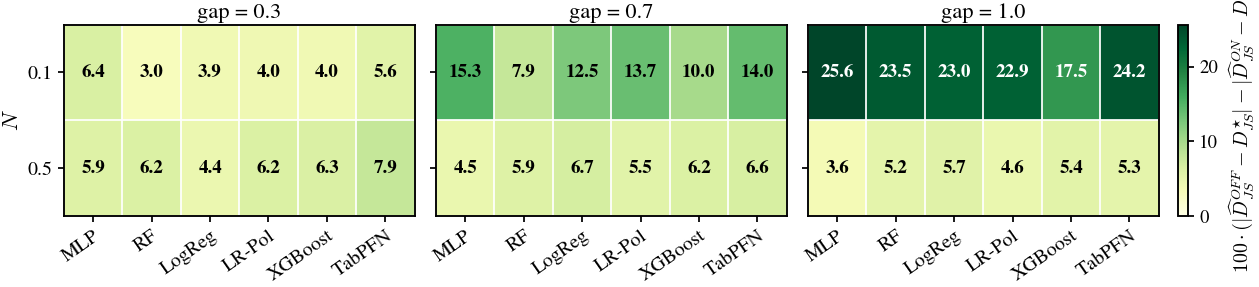

Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_13/figures/uc13_off_minus_on_abs_error_heatmaps_x100_positive_readable.png
Figura guardada en: /home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments/results_discriminators/use_case_13/figures/uc13_off_minus_on_abs_error_heatmaps_x100_positive_readable.pdf


In [38]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles

# =========================
# CONFIG
# =========================
BASE = Path("/home/alba/snap/snapd-desktop-integration/jensenshannondivergence/experiments")

GAPS = [0.3, 0.7, 1.0]
N_VALUES = [0.1, 0.5]

METHODS = ["MLP", "RF", "LogReg", "LogRegPol", "XGBoost", "TabPFN"]
METHOD_LABELS = ["MLP", "RF", "LogReg", "LR-Pol", "XGBoost", "TabPFN"]

ON_CASE = "use_case_13/ON"
OFF_CASE = "use_case_13/OFF"
SCALE = 100.0

OUT_DIR = BASE / "results_discriminators" / "use_case_13" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# STYLE
# =========================
try:
    style = bundles.neurips2023(usetex=False, nrows=1, ncols=3)
except Exception:
    style = bundles.icml2022()

plt.rcParams.update({
    **style,
    "text.usetex": False,
    "figure.figsize": (7.05, 1.65),
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 8.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 9,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
})

# =========================
# HELPERS
# =========================
def n_folder(n):
    return f"{float(n):.1f}_2000_2000"


def gap_folder(gap):
    return f"gap_{float(gap):.1f}"


def seeds_path(method, use_case_name, gap, n):
    return (
        BASE
        / f"results_{method}"
        / use_case_name
        / gap_folder(gap)
        / n_folder(n)
        / "seeds_js.csv"
    )


def read_values(path, column):
    if path is None or not path.exists():
        return np.asarray([], dtype=float)

    df = pd.read_csv(path, na_values=["-", ""])

    if column not in df.columns:
        return np.asarray([], dtype=float)

    return pd.to_numeric(df[column], errors="coerce").dropna().to_numpy(float)


def mean_abs_error(method, use_case_name, gap, n):
    path = seeds_path(method, use_case_name, gap, n)

    gt = read_values(path, "Ground Truth MC JS")
    est = read_values(path, "Disc JS")

    min_len = min(len(gt), len(est))

    if min_len == 0:
        return np.nan

    return float(np.nanmean(np.abs(est[:min_len] - gt[:min_len])))


def improvement_off_minus_on(method, gap, n):
    off_err = mean_abs_error(method, OFF_CASE, gap, n)
    on_err = mean_abs_error(method, ON_CASE, gap, n)

    if pd.isna(off_err) or pd.isna(on_err):
        return np.nan

    return SCALE * (off_err - on_err)


# =========================
# BUILD MATRICES
# =========================
matrices = {}
all_values = []

for gap in GAPS:
    matrix = np.full((len(N_VALUES), len(METHODS)), np.nan)

    for i, n in enumerate(N_VALUES):
        for j, method in enumerate(METHODS):
            value = improvement_off_minus_on(method, gap, n)
            matrix[i, j] = value

            if not np.isnan(value):
                all_values.append(value)

    matrices[gap] = matrix

if len(all_values) == 0:
    raise RuntimeError("No se encontraron valores válidos para construir los heatmaps.")

vmin = 0.0
vmax = np.nanmax(all_values)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, len(GAPS), sharey=True)

for ax, gap in zip(axes, GAPS):
    matrix = matrices[gap]

    im = ax.imshow(
        matrix,
        cmap="YlGn",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(rf"gap = {gap:.1f}", pad=3)

    ax.set_xticks(np.arange(len(METHODS)))
    ax.set_xticklabels(METHOD_LABELS, rotation=35, ha="right", rotation_mode="anchor")

    ax.set_yticks(np.arange(len(N_VALUES)))
    ax.set_yticklabels([f"{n:.1f}" for n in N_VALUES])

    ax.tick_params(axis="both", length=2.5, pad=2)

    # Cell borders, subtle but improves readability
    ax.set_xticks(np.arange(-0.5, len(METHODS), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(N_VALUES), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(len(N_VALUES)):
        for j in range(len(METHODS)):
            value = matrix[i, j]

            if np.isnan(value):
                text = "-"
                color = "black"
            else:
                text = f"{value:.1f}"
                norm_value = (value - vmin) / max(vmax - vmin, 1e-12)
                color = "white" if norm_value > 0.62 else "black"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7.6,
                fontweight="semibold",
                color=color,
            )

axes[0].set_ylabel(r"$N$", labelpad=2)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.032,
    pad=0.018,
)

cbar.set_label(
    r"$100\cdot(|\widehat{D}_{JS}^{OFF}-D_{JS}^{\star}|"
    r"-|\widehat{D}_{JS}^{ON}-D_{JS}^{\star}|)$",
    labelpad=4,
    fontsize=8,
)

cbar.ax.tick_params(labelsize=7.5, length=2.5, pad=2)

plt.subplots_adjust(
    left=0.055,
    right=0.915,
    bottom=0.34,
    top=0.86,
    wspace=0.10,
)

# =========================
# SAVE
# =========================
out_png = OUT_DIR / "uc13_off_minus_on_abs_error_heatmaps_x100_positive_readable.png"
out_pdf = OUT_DIR / "uc13_off_minus_on_abs_error_heatmaps_x100_positive_readable.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.015)
fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.015)

plt.show()
plt.close(fig)

print(f"Figura guardada en: {out_png.resolve()}")
print(f"Figura guardada en: {out_pdf.resolve()}")


# TABLE 9


In [39]:
from pathlib import Path

import pandas as pd

uc14_table = pd.DataFrame([
    {'Generator': 'VAE', 'Dataset': 'adult', 'MLP': '0.04 $\\pm$ 0.03', 'RF': '0.09 $\\pm$ 0.04', 'LogReg': '0.02 $\\pm$ 0.02', 'XGBoost': '0.46 $\\pm$ 0.03', 'LR-Pol': '0.02 $\\pm$ 0.02', 'TabPFN': '0.29 $\\pm$ 0.03', 'Syndat': '0.01 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
    {'Generator': 'VAE', 'Dataset': 'intrusion', 'MLP': '0.70 $\\pm$ 0.12', 'RF': '0.95 $\\pm$ 0.02', 'LogReg': '0.00 $\\pm$ 0.00', 'XGBoost': '0.96 $\\pm$ 0.02', 'LR-Pol': '0.00 $\\pm$ 0.01', 'TabPFN': '0.99 $\\pm$ 0.00', 'Syndat': '0.04 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
    {'Generator': 'CTGAN', 'Dataset': 'adult', 'MLP': '0.03 $\\pm$ 0.01', 'RF': '0.11 $\\pm$ 0.03', 'LogReg': '0.03 $\\pm$ 0.01', 'XGBoost': '0.42 $\\pm$ 0.07', 'LR-Pol': '0.02 $\\pm$ 0.01', 'TabPFN': '0.24 $\\pm$ 0.02', 'Syndat': '0.02 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
    {'Generator': 'CTGAN', 'Dataset': 'intrusion', 'MLP': '0.24 $\\pm$ 0.10', 'RF': '0.73 $\\pm$ 0.06', 'LogReg': '0.03 $\\pm$ 0.02', 'XGBoost': '0.86 $\\pm$ 0.04', 'LR-Pol': '0.07 $\\pm$ 0.04', 'TabPFN': '0.81 $\\pm$ 0.03', 'Syndat': '0.02 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
])

uc14_time_table = pd.DataFrame([
    {'Generator': 'VAE', 'Dataset': 'adult', 'MLP': '29.04 $\\pm$ 5.97', 'RF': '119.54 $\\pm$ 8.54', 'LogReg': '40.21 $\\pm$ 1.21', 'XGBoost': '72.82 $\\pm$ 4.59', 'LR-Pol': '743.07 $\\pm$ 98.31', 'TabPFN': '0.47 $\\pm$ 0.21', 'Syndat': '0.01 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
    {'Generator': 'VAE', 'Dataset': 'intrusion', 'MLP': '53.62 $\\pm$ 22.31', 'RF': '119.61 $\\pm$ 11.68', 'LogReg': '92.08 $\\pm$ 10.16', 'XGBoost': '63.14 $\\pm$ 1.84', 'LR-Pol': '1878.24 $\\pm$ 498.49', 'TabPFN': '0.49 $\\pm$ 0.16', 'Syndat': '0.02 $\\pm$ 0.00', 'Synthcity': '0.02 $\\pm$ 0.00'},
    {'Generator': 'CTGAN', 'Dataset': 'adult', 'MLP': '27.83 $\\pm$ 7.16', 'RF': '120.73 $\\pm$ 12.25', 'LogReg': '39.92 $\\pm$ 2.61', 'XGBoost': '69.97 $\\pm$ 4.38', 'LR-Pol': '783.67 $\\pm$ 96.29', 'TabPFN': '0.32 $\\pm$ 0.07', 'Syndat': '0.01 $\\pm$ 0.00', 'Synthcity': '0.01 $\\pm$ 0.00'},
    {'Generator': 'CTGAN', 'Dataset': 'intrusion', 'MLP': '53.66 $\\pm$ 46.11', 'RF': '125.71 $\\pm$ 2.09', 'LogReg': '129.30 $\\pm$ 28.57', 'XGBoost': '71.08 $\\pm$ 1.13', 'LR-Pol': '2452.68 $\\pm$ 103.78', 'TabPFN': '0.41 $\\pm$ 0.00', 'Syndat': '0.02 $\\pm$ 0.00', 'Synthcity': '0.02 $\\pm$ 0.00'},
])

caption = (
    r'Low-data setting (10\%) for adult and intrusion with VAE and CTGAN. '
    r'Rows report mean $\pm$ standard deviation over seeds for '
    r'$\widehat{D}_{\mathrm{JS}}$ and runtime.'
)
label = 'tab:uc14_low_data_adult_intrusion_vae_ctgan'

header = 'Generator & Dataset & MLP & RF & LogReg & XGBoost & LR-Pol & TabPFN & Syndat & Synthcity ' + r'\\'
section_divider = r'\midrule'
multicolumn_js = r'\multicolumn{10}{c}{\textbf{$\widehat{D}_{\mathrm{JS}}$}} ' + r'\\'
multicolumn_time = r'\multicolumn{10}{c}{\textbf{Time (s)}} ' + r'\\'

lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\scriptsize',
    r'\setlength{\tabcolsep}{2.2pt}',
    rf'\caption{{{caption}}}',
    rf'\label{{{label}}}',
    r'\resizebox{\textwidth}{!}{%',
    r'\begin{tabular}{llrrrrrrrr}',
    r'\toprule',
    header,
    section_divider,
    multicolumn_js,
    section_divider,
]

for _, row in uc14_table.iterrows():
    lines.append(
        f"{row['Generator']} & {row['Dataset']} & {row['MLP']} & {row['RF']} & {row['LogReg']} & {row['XGBoost']} & {row['LR-Pol']} & {row['TabPFN']} & {row['Syndat']} & {row['Synthcity']} " + r'\\'
    )

lines.extend([
    section_divider,
    multicolumn_time,
    section_divider,
])

for _, row in uc14_time_table.iterrows():
    lines.append(
        f"{row['Generator']} & {row['Dataset']} & {row['MLP']} & {row['RF']} & {row['LogReg']} & {row['XGBoost']} & {row['LR-Pol']} & {row['TabPFN']} & {row['Syndat']} & {row['Synthcity']} " + r'\\'
    )

lines.extend([
    r'\bottomrule',
    r'\end{tabular}%',
    r'}',
    r'\end{table}',
])

latex = '\n'.join(lines)

out_dir = Path('results_discriminators/use_case_14/tables')
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / 'uc14_low_data_adult_intrusion_vae_ctgan.tex'
out_file.write_text(latex, encoding='utf-8')

display(uc14_table)
display(uc14_time_table)
print(latex)
print(f'Tabla LaTeX guardada en: {out_file.resolve()}')

,Generator,Dataset,MLP,RF,LogReg,XGBoost,LR-Pol,TabPFN,Syndat,Synthcity
0,VAE,adult,0.04 $\pm$ 0.03,0.09 $\pm$ 0.04,0.02 $\pm$ 0.02,0.46 $\pm$ 0.03,0.02 $\pm$ 0.02,0.29 $\pm$ 0.03,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,0.70 $\pm$ 0.12,0.95 $\pm$ 0.02,0.00 $\pm$ 0.00,0.96 $\pm$ 0.02,0.00 $\pm$ 0.01,0.99 $\pm$ 0.00,0.04 $\pm$ 0.00,0.01 $\pm$ 0.00
2,CTGAN,adult,0.03 $\pm$ 0.01,0.11 $\pm$ 0.03,0.03 $\pm$ 0.01,0.42 $\pm$ 0.07,0.02 $\pm$ 0.01,0.24 $\pm$ 0.02,0.02 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,0.24 $\pm$ 0.10,0.73 $\pm$ 0.06,0.03 $\pm$ 0.02,0.86 $\pm$ 0.04,0.07 $\pm$ 0.04,0.81 $\pm$ 0.03,0.02 $\pm$ 0.00,0.01 $\pm$ 0.00


,Generator,Dataset,MLP,RF,LogReg,XGBoost,LR-Pol,TabPFN,Syndat,Synthcity
0,VAE,adult,29.04 $\pm$ 5.97,119.54 $\pm$ 8.54,40.21 $\pm$ 1.21,72.82 $\pm$ 4.59,743.07 $\pm$ 98.31,0.47 $\pm$ 0.21,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
1,VAE,intrusion,53.62 $\pm$ 22.31,119.61 $\pm$ 11.68,92.08 $\pm$ 10.16,63.14 $\pm$ 1.84,1878.24 $\pm$ 498.49,0.49 $\pm$ 0.16,0.02 $\pm$ 0.00,0.02 $\pm$ 0.00
2,CTGAN,adult,27.83 $\pm$ 7.16,120.73 $\pm$ 12.25,39.92 $\pm$ 2.61,69.97 $\pm$ 4.38,783.67 $\pm$ 96.29,0.32 $\pm$ 0.07,0.01 $\pm$ 0.00,0.01 $\pm$ 0.00
3,CTGAN,intrusion,53.66 $\pm$ 46.11,125.71 $\pm$ 2.09,129.30 $\pm$ 28.57,71.08 $\pm$ 1.13,2452.68 $\pm$ 103.78,0.41 $\pm$ 0.00,0.02 $\pm$ 0.00,0.02 $\pm$ 0.00


\begin{table}[ht]
\centering
\scriptsize
\setlength{\tabcolsep}{2.2pt}
\caption{Low-data setting (10\%) for adult and intrusion with VAE and CTGAN. Rows report mean $\pm$ standard deviation over seeds for $\widehat{D}_{\mathrm{JS}}$ and runtime.}
\label{tab:uc14_low_data_adult_intrusion_vae_ctgan}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrrrr}
\toprule
Generator & Dataset & MLP & RF & LogReg & XGBoost & LR-Pol & TabPFN & Syndat & Synthcity \\
\midrule
\multicolumn{10}{c}{\textbf{$\widehat{D}_{\mathrm{JS}}$}} \\
\midrule
VAE & adult & 0.04 $\pm$ 0.03 & 0.09 $\pm$ 0.04 & 0.02 $\pm$ 0.02 & 0.46 $\pm$ 0.03 & 0.02 $\pm$ 0.02 & 0.29 $\pm$ 0.03 & 0.01 $\pm$ 0.00 & 0.01 $\pm$ 0.00 \\
VAE & intrusion & 0.70 $\pm$ 0.12 & 0.95 $\pm$ 0.02 & 0.00 $\pm$ 0.00 & 0.96 $\pm$ 0.02 & 0.00 $\pm$ 0.01 & 0.99 $\pm$ 0.00 & 0.04 $\pm$ 0.00 & 0.01 $\pm$ 0.00 \\
CTGAN & adult & 0.03 $\pm$ 0.01 & 0.11 $\pm$ 0.03 & 0.03 $\pm$ 0.01 & 0.42 $\pm$ 0.07 & 0.02 $\pm$ 0.01 & 0.24 $\pm$ 0.02 & 0.02 $\pm$ 0.00 & 0